# Training of all models for 0MA+enumeration queries

In [2]:
!pip install numpy==1.26.0
!pip install scikit-learn==1.5.0
!pip install statsmodels==0.14.2
!pip install matplotlib==3.9.0
!pip install seaborn==0.13.2
!pip install torch==1.13.1
!pip install tqdm==4.66.4
!pip install dhg==0.9.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 6.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 4.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 KB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 6.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 KB 4.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 6.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 KB 7.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 KB 8.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 9.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 KB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.svm import LinearSVR
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from torch import nn
from torch.utils.data import DataLoader
import dhg
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
import pickle
import scipy.stats as stats

In [4]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['figure.dpi'] = 600

### Import the data

In [198]:
system = 'POS'
system = 'DDB'
system = 'SPA'

#queries = '0ma'
#queries = 'enum'
queries = 'all'

In [199]:
if system == 'POS':

    file_path = 'results/features_times_POS_extra_full_enum_infos.csv'
    df1 = pd.read_csv(file_path)
    df1['0ma'] = 0

    file_path = 'results/features_times_POS_extra_infos.csv'
    df2 = pd.read_csv(file_path)
    df2['0ma'] = 1

    cols = ['bench', 'query', 'orig/rewr(med)', 'orig(med)', 'rewr(med)',
        '0ma',
       '#relations', '#conditions', '#filters', '#joins', 'total cost',
       'min(table rows)', 'max(table rows)', 'mean(table rows)',
       'q25(table rows)', 'median(table rows)', 'q75(table rows)',
       'min(join rows)', 'max(join rows)', 'mean(join rows)', 'q25(join rows)',
       'median(join rows)', 'q75(join rows)', 'depth', 'min(container counts)',
       'max(container counts)', 'mean(container counts)',
       'q25(container counts)', 'median(container counts)',
       'q75(container counts)', 'min(branching factors)',
       'max(branching factors)', 'mean(branching factors)',
       'median(branching factors)', 'q25(branching factors)',
       'q75(branching factors)']

    df1 = df1[cols]
    df2 = df2[cols]
    if queries == 'all':
        df = pd.concat([df1, df2]).reset_index(drop=True)
    if queries == '0ma':
        df = df2
    if queries == 'enum':
        df = df1
    df.head()

if system == 'DDB':

    file_path = 'results/features_times_DDB_extra_full_enum_infos.csv'
    df1 = pd.read_csv(file_path)
    df1['0ma'] = 0

    file_path = 'results/features_times_DDB_extra_infos.csv'
    df2 = pd.read_csv(file_path)
    df2['0ma'] = 1

    cols = ['bench', 'query', 'orig/rewr(med)', 'orig(med)', 'rewr(med)',
        '0ma',
       '#relations', '#conditions', '#filters', '#joins',
       'min(est. cardinality)', 'max(est. cardinality)',
       'mean(est. cardinality)', 'q25(est. cardinality)',
       'median(est. cardinality)', 'q75(est. cardinality)', 'depth',
       'min(container counts)', 'max(container counts)',
       'mean(container counts)', 'q25(container counts)',
       'median(container counts)', 'q75(container counts)',
       'min(branching factors)', 'max(branching factors)',
       'mean(branching factors)', 'median(branching factors)',
       'q25(branching factors)', 'q75(branching factors)']

    df1 = df1[cols]
    df2 = df2[cols]
    if queries == 'all':
        df = pd.concat([df1, df2]).reset_index(drop=True)
    if queries == '0ma':
        df = df2
    if queries == 'enum':
        df = df1
    df.head()

if system == 'SPA':

    file_path = 'results/features_times_SPA_extra_full_enum_infos.csv'
    df1 = pd.read_csv(file_path)
    df1['0ma'] = 0
    
    file_path = 'results/features_times_SPA_infos.csv'
    df2 = pd.read_csv(file_path)
    df2_features = pd.read_csv('results/features_times_POS_extra_infos.csv')
    df2_features = df2_features[['query', 'total cost', 'min(table rows)', 'max(table rows)', 'mean(table rows)', 'q25(table rows)', 'median(table rows)', 'q75(table rows)', 'min(join rows)', 'max(join rows)', 'mean(join rows)', 'q25(join rows)', 'median(join rows)', 'q75(join rows)']]

    df2 = pd.merge(df2, df2_features, on = 'query', how='inner')

    df2['0ma'] = 1

    cols = ['bench', 'query', 'orig/rewr(med)', 'orig(med)', 'rewr(med)',
        '0ma',
       '#joins', 'total cost', 'min(table rows)', 'max(table rows)',
       'mean(table rows)', 'q25(table rows)', 'median(table rows)',
       'q75(table rows)', 'min(join rows)', 'max(join rows)',
       'mean(join rows)', 'q25(join rows)', 'median(join rows)',
       'q75(join rows)', 'depth', 'min(container counts)',
       'max(container counts)', 'mean(container counts)',
       'q25(container counts)', 'median(container counts)',
       'q75(container counts)', 'min(branching factors)',
       'max(branching factors)', 'mean(branching factors)',
       'median(branching factors)', 'q25(branching factors)',
       'q75(branching factors)']

    df1 = df1[cols]
    df2 = df2[cols]
    if queries == 'all':
        df = pd.concat([df1, df2]).reset_index(drop=True)
    if queries == '0ma':
        df = df2
    if queries == 'enum':
        df = df1
    df.head()

# note: there was an inconsistency in the query name of 16-03-SpDtCuGrGe / 16-03-SpDtCuGrGeA which was manually fixed in the hg file
hg_file = 'results/hypergraphs_0MA.csv'
hg_df = pd.read_csv(hg_file)

hg_dict = hg_df[['query', 'hypergraph']].set_index('query')['hypergraph'].to_dict()

def get_hg(row):
    q = row['query']
    q = q.split('-aug')[0]
    q = q.split('-full')[0]
    return hg_dict[q]

def is_base(row):
    q = row['query']
    return not "aug" in q
    
df['hypergraph'] = df.apply(lambda row: get_hg(row), axis=1)

df["hypergraph"] = df["hypergraph"].apply(lambda x: pickle.loads(eval(x)))

df['is_base'] = df.apply(lambda row: is_base(row), axis=1)

In [200]:
df.shape

(4677, 35)

#### Delete those examples, where both methods gave a timeout

Some queries did not finish the evaluation within our timeout (100 sec). Therefore, we cannot conclude which variantis the better one and we delete those samples.

In cases where only one of the versions is giving a timeout, we set it the runtime to 100 to be able to work with them.

In [201]:
if system != 'DDB':
    df["max(join rows)"] = df["max(join rows)"].astype(float)

df = df[df["orig/rewr(med)"] != "-"]
df['orig(med)'] = df['orig(med)'].replace("TO", 100)
df['rewr(med)'] = df['rewr(med)'].replace("TO", 100)
df["orig(med)"] = df["orig(med)"].astype(float)
df["rewr(med)"] = df["rewr(med)"].astype(float)
df = df[df['rewr(med)'].notnull()]

In [202]:
#pd.set_option('display.max_rows', 5000)
#pd.set_option('display.max_rows', 500)
df

,bench,query,orig/rewr(med),orig(med),rewr(med),0ma,#joins,total cost,min(table rows),max(table rows),...,median(container counts),q75(container counts),min(branching factors),max(branching factors),mean(branching factors),median(branching factors),q25(branching factors),q75(branching factors),hypergraph,is_base
0,STATS,001-014-full1,orig,0.037880,0.082953,0,2,11475.41,1,168966,...,1.0,1.0,2,2,2.0,2.0,2.0,2.0,"Hypergraph(num_v=17, num_e=3)",True
1,STATS,001-014-full2,orig,0.037785,0.082452,0,2,11475.41,1,168966,...,1.0,1.0,2,2,2.0,2.0,2.0,2.0,"Hypergraph(num_v=17, num_e=3)",True
2,STATS,001-014-full3,orig,0.038273,0.085486,0,2,11475.41,1,168966,...,1.0,1.0,2,2,2.0,2.0,2.0,2.0,"Hypergraph(num_v=17, num_e=3)",True
3,STATS,001-014-augF1-full1,orig,0.037612,0.084220,0,2,11412.99,1,168966,...,1.0,1.0,2,2,2.0,2.0,2.0,2.0,"Hypergraph(num_v=17, num_e=3)",False
4,STATS,001-014-augF1-full2,orig,0.037726,0.083104,0,2,11412.99,1,168966,...,1.0,1.0,2,2,2.0,2.0,2.0,2.0,"Hypergraph(num_v=17, num_e=3)",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4672,HETIO,16-03-SpDtCuGrGe-augA6,rewr,100.000000,1.882625,1,10,135057.78,137,438672,...,1.0,1.0,1,4,2.0,2.0,1.0,2.0,"Hypergraph(num_v=22, num_e=11)",False
4673,HETIO,16-03-SpDtCuGrGe-augA7,rewr,100.000000,2.010028,1,10,135057.78,137,438672,...,1.0,1.0,1,3,2.0,2.0,1.0,3.0,"Hypergraph(num_v=22, num_e=11)",False
4674,HETIO,16-03-SpDtCuGrGe-augA8,rewr,100.000000,1.830129,1,10,135979.78,137,438672,...,1.0,1.0,1,4,2.0,2.0,1.0,2.0,"Hypergraph(num_v=22, num_e=11)",False
4675,HETIO,16-03-SpDtCuGrGe-augA9,rewr,100.000000,1.587047,1,10,135979.78,137,438672,...,1.0,1.0,1,3,2.0,2.0,1.0,3.0,"Hypergraph(num_v=22, num_e=11)",False


#### Get the feature matrix

Get the features matrix X and the response variables y1 and y1, where once the rewritting time and the evaluation time are taken into consideration and once only the evaluation time. Additionally the response variables have to have numbers in it and we assign 1 = rewr and 0 = orig.

In [203]:
X = df.iloc[:, 5:-2]
df_base = df[df["is_base"] == True]
X_base = df_base.iloc[:, 5:-2]
X.head()

,0ma,#joins,total cost,min(table rows),max(table rows),mean(table rows),q25(table rows),median(table rows),q75(table rows),min(join rows),...,mean(container counts),q25(container counts),median(container counts),q75(container counts),min(branching factors),max(branching factors),mean(branching factors),median(branching factors),q25(branching factors),q75(branching factors)
0,0,2,11475.41,1,168966,56650.666667,493.0,985.0,84975.5,84.0,...,1.133333,1.0,1.0,1.0,2,2,2.0,2.0,2.0,2.0
1,0,2,11475.41,1,168966,56650.666667,493.0,985.0,84975.5,84.0,...,1.133333,1.0,1.0,1.0,2,2,2.0,2.0,2.0,2.0
2,0,2,11475.41,1,168966,56650.666667,493.0,985.0,84975.5,84.0,...,1.133333,1.0,1.0,1.0,2,2,2.0,2.0,2.0,2.0
3,0,2,11412.99,1,168966,56588.333333,399.5,798.0,84882.0,68.0,...,1.133333,1.0,1.0,1.0,2,2,2.0,2.0,2.0,2.0
4,0,2,11412.99,1,168966,56588.333333,399.5,798.0,84882.0,68.0,...,1.133333,1.0,1.0,1.0,2,2,2.0,2.0,2.0,2.0


#### Log-transformations

The basic features do not need log transformations. For the SVM and MLP models, log-transformations significantly increase performance, while it does not change decision tree and random forest performance. For kNN, it degrades the performance.

In [204]:
columns_to_log = ['total cost', 'min(table rows)', 'max(table rows)',
       'mean(table rows)', 'q25(table rows)', 'median(table rows)',
       'q75(table rows)', 'min(join rows)', 'max(join rows)',
       'mean(join rows)', 'q25(join rows)', 'median(join rows)',
       'q75(join rows)']

if system == 'DDB':
    columns_to_log = ['min(est. cardinality)', 'max(est. cardinality)',
       'mean(est. cardinality)', 'q25(est. cardinality)',
       'median(est. cardinality)', 'q75(est. cardinality)']

X[columns_to_log] = X[columns_to_log].apply(np.log)

#### Classification response

Get the column(s) where we have "orig" or "rewr", depending on which method was faster. We now want to encode this as 0 (evaluating the original query faster) and 1 (evaluating the rewritten query faster).

In [205]:
mapping = {'orig': 0, 'rewr': 1}
y1 = df['orig/rewr(med)'].map(mapping)
y1_base = df_base['orig/rewr(med)'].map(mapping)
#y1.head()

The number of appearances of original and rewritten is very balanced.

In [206]:
y1.value_counts()

orig/rewr(med)
0    2715
1    1729
Name: count, dtype: int64

In [207]:
count = y1.value_counts().tolist()[::-1] + ["-"]
count = pd.Series(count)
count.index = ["rewr", "orig", "equal"]
count

rewr     1729
orig     2715
equal       -
dtype: object

In [208]:
df["orig/rewr(med)"].value_counts()

orig/rewr(med)
orig    2715
rewr    1729
Name: count, dtype: int64

#### Train-validation-test split

We split the dataset such that each benchmark dataset is represented in the train and in the test set (stratification). We do a 80% train, 10% validation and 10% test split.

In [209]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, stratify=df["bench"], random_state=20)
X_val, X_test, y1_val, y1_test = train_test_split(X_test, y1_test, test_size=0.5, stratify=df.loc[X_test.index]["bench"], random_state=20)

In [228]:
ablation = True
ablation = False

X_train, X_test, y1_train, y1_test = train_test_split(df, y1, test_size=0.2, stratify=df["bench"], random_state=20)
X_val, X_test, y1_val, y1_test = train_test_split(X_test, y1_test, test_size=0.5, stratify=df.loc[X_test.index]["bench"], random_state=20)


if ablation:
    y1_train = y1_train[X_train["is_base"] == True]
    X_train = X_train[X_train["is_base"] == True].iloc[:, 5:-3]
    X_test = X_test.iloc[:, 5:-3]
else:
    X_train = X_train.iloc[:, 5:-3]
    X_test = X_test.iloc[:, 5:-3]
    
    #X_train, X_test, y1_train, y1_test = train_test_split(X_base, y1_base, test_size=0.2, random_state=20)
    #X_val, X_test, y1_val, y1_test = train_test_split(X_test, y1_test, test_size=0.5, random_state=20)

In [229]:
#y1
X_train

,0ma,#joins,total cost,min(table rows),max(table rows),mean(table rows),q25(table rows),median(table rows),q75(table rows),min(join rows),...,mean(container counts),q25(container counts),median(container counts),q75(container counts),min(branching factors),max(branching factors),mean(branching factors),median(branching factors),q25(branching factors),q75(branching factors)
2256,1,5,2.744144e+04,19167,154454,7.442783e+04,41105.25,66742.5,96861.75,1.117700e+04,...,1.166667,1.0,1.0,1.0,5,5,5.000000,5.0,5.00,5.00
2125,1,3,9.394590e+03,1,101536,2.816125e+04,4.75,5554.0,33710.50,1.000000e+00,...,1.130435,1.0,1.0,1.0,3,3,3.000000,3.0,3.00,3.00
4602,1,8,4.775126e+04,137,173134,4.216122e+04,1510.00,6714.0,20945.00,4.460000e+02,...,1.200000,1.0,1.0,1.0,1,3,2.000000,2.0,1.75,2.25
3004,1,2,2.630080e+04,40325,79647,6.623900e+04,59535.00,78745.0,79196.00,7.964700e+04,...,1.166667,1.0,1.0,1.0,2,2,2.000000,2.0,2.00,2.00
3653,1,8,3.232623e+10,437444,1049866,8.457253e+05,437444.00,1049866.0,1049866.00,2.942144e+06,...,1.058824,1.0,1.0,1.0,1,2,1.142857,1.0,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,0,5,1.995196e+04,1,325053,1.015657e+05,3734.50,57029.0,152491.50,1.340000e+02,...,1.156250,1.0,1.0,1.0,5,5,5.000000,5.0,5.00,5.00
2640,1,5,1.665666e+04,1,192979,6.032133e+04,3261.50,44398.0,79051.50,7.800000e+01,...,1.172414,1.0,1.0,1.0,5,5,5.000000,5.0,5.00,5.00
4349,1,6,2.363065e+04,1,678887,1.253244e+05,1.00,1.0,99190.00,1.000000e+00,...,1.272727,1.0,1.0,1.0,1,3,2.000000,2.0,1.50,2.50
3854,1,7,9.163328e+20,11879671,28511210,2.643227e+07,28511210.00,28511210.0,28511210.00,2.040287e+09,...,1.230769,1.0,1.0,1.0,1,3,1.750000,1.5,1.00,2.25


### Facts about the test set and runtime differences

In [230]:
y1_test.value_counts()

orig/rewr(med)
0    279
1    166
Name: count, dtype: int64

In [231]:
#df["diff rewr-orig"] = df["rewr(med)"] - df["orig(med)"]
df["diff rewr-orig"] = np.where(
    df["rewr(med)"] == 100, 100,
    np.where(
        df["orig(med)"] == 100, -100, 
        df["rewr(med)"] - df["orig(med)"] 
    )
)


## Train + test set

In [232]:
diff_rewr = df.loc[df["diff rewr-orig"] < 0]
diff_orig = df.loc[df["diff rewr-orig"] >= 0]

In [233]:
bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']

diff_rewr["cut"] = pd.cut(abs(diff_rewr["diff rewr-orig"]), bins=bins, labels=labels)
diff_orig["cut"] = pd.cut(abs(diff_orig["diff rewr-orig"]), bins=bins, labels=labels)

table_rewr = diff_rewr.groupby('cut').size().reset_index(name = "rewr")
table_orig = diff_orig.groupby('cut').size().reset_index(name = "orig")

table = pd.merge(table_rewr, table_orig, on='cut', how='outer')
table = table.set_index('cut').T
#table.index = ['FP', 'FN']
table

/tmp/ipykernel_40/1750407932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_rewr["cut"] = pd.cut(abs(diff_rewr["diff rewr-orig"]), bins=bins, labels=labels)
/tmp/ipykernel_40/1750407932.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_orig["cut"] = pd.cut(abs(diff_orig["diff rewr-orig"]), bins=bins, labels=labels)
/tmp/ipykernel_40/1750407932.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to re

cut,0.01,0.1,1,10,100,TO
rewr,45,227,461,388,184,424
orig,62,835,1599,127,88,4


### Test set

In [234]:
diff_rewr = df.loc[y1_test[y1_test == 1].index]
diff_orig = df.loc[y1_test[y1_test == 0].index]

In [235]:
bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']

diff_rewr["cut"] = pd.cut(abs(diff_rewr["diff rewr-orig"]), bins=bins, labels=labels)
diff_orig["cut"] = pd.cut(abs(diff_orig["diff rewr-orig"]), bins=bins, labels=labels)

table_rewr = diff_rewr.groupby('cut').size().reset_index(name = "rewr")
table_orig = diff_orig.groupby('cut').size().reset_index(name = "orig")

table = pd.merge(table_rewr, table_orig, on='cut', how='outer')
table = table.set_index('cut').T
#table.index = ['FP', 'FN']
table

/tmp/ipykernel_40/1750407932.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table_rewr = diff_rewr.groupby('cut').size().reset_index(name = "rewr")
/tmp/ipykernel_40/1750407932.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table_orig = diff_orig.groupby('cut').size().reset_index(name = "orig")


cut,0.01,0.1,1,10,100,TO
rewr,6,27,43,37,12,41
orig,11,82,162,13,10,1


## Regression y

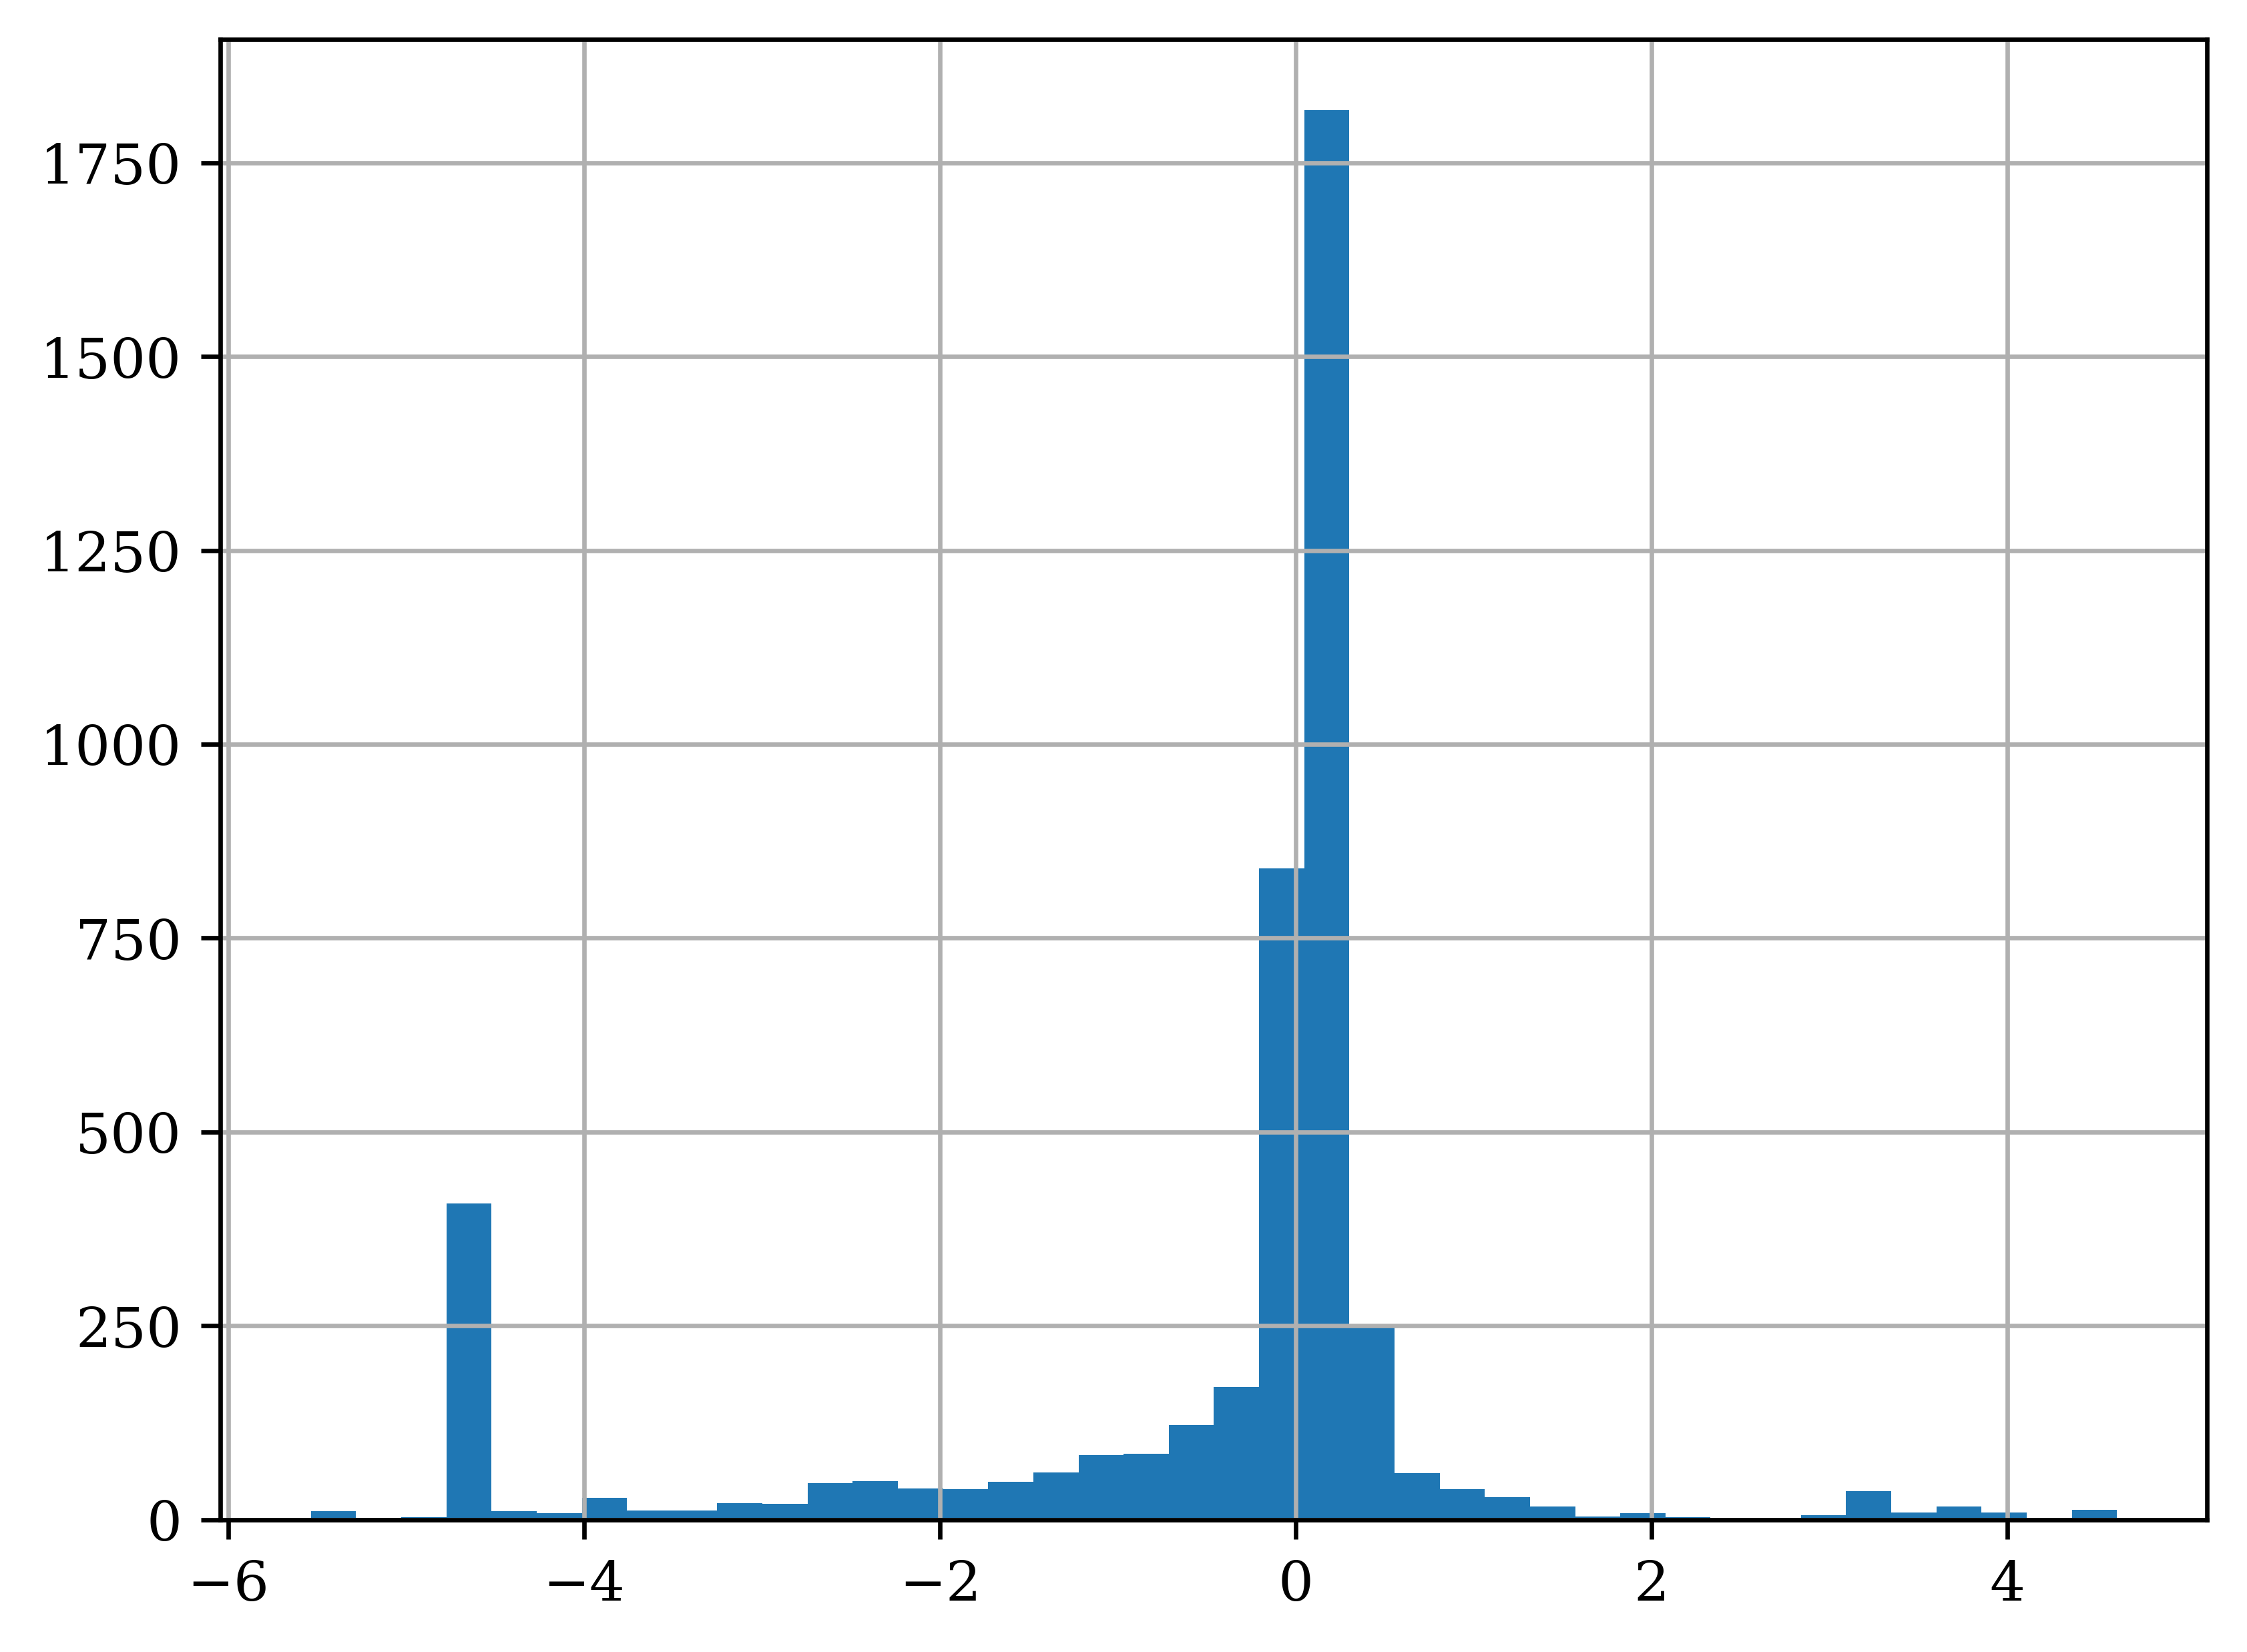

In [236]:
y1_diff = df["diff rewr-orig"]

y1_diff_log = np.sign(y1_diff) * np.log(abs(y1_diff) +1)
y1_diff_log.hist(bins = 40)
plt.show()

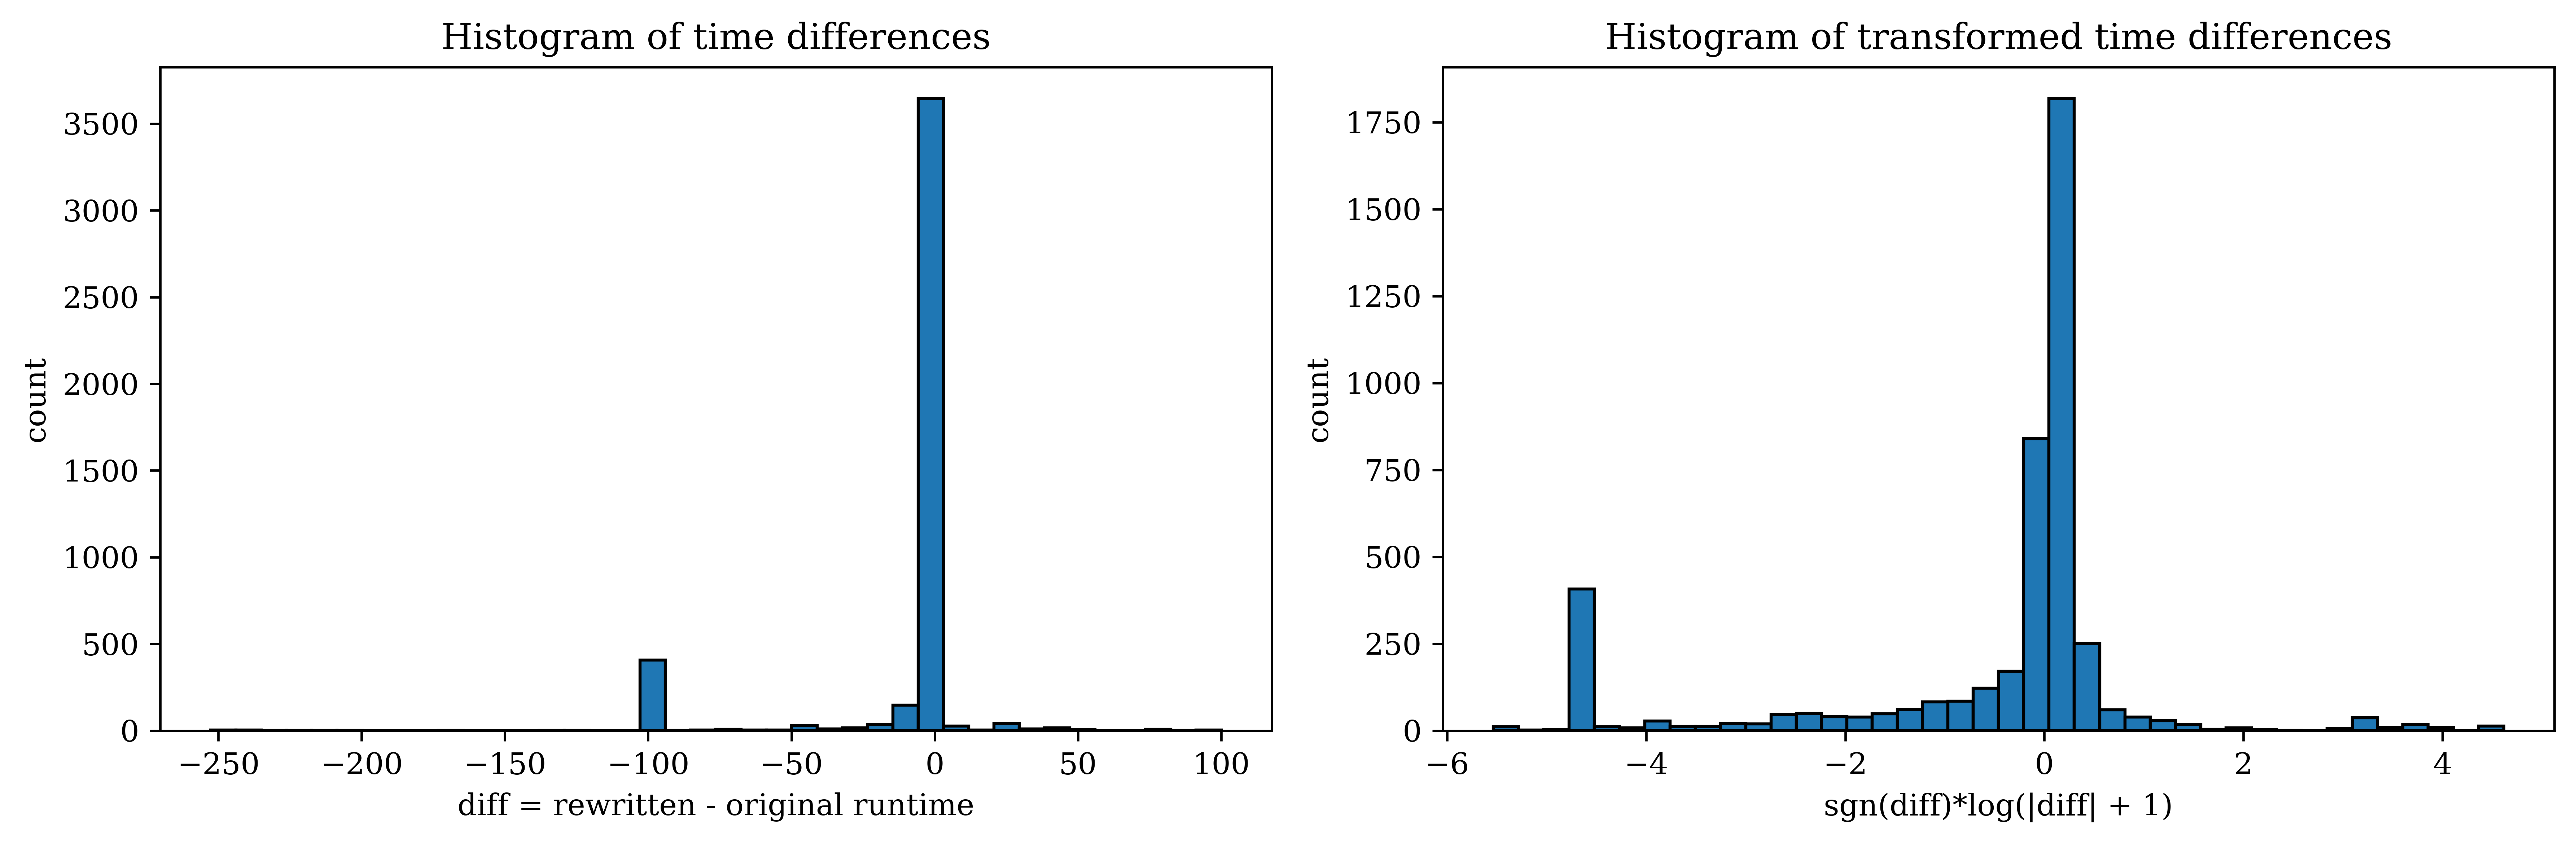

In [237]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(y1_diff, bins=40, edgecolor='black')
axs[0].set_title('Histogram of time differences')
axs[0].set_ylabel("count")
axs[0].set_xlabel("diff = rewritten - original runtime")

# Create the second histogram
y1_diff_log = np.sign(y1_diff) * np.log(abs(y1_diff) + 1)
axs[1].hist(y1_diff_log, bins=40, edgecolor='black')
axs[1].set_title('Histogram of transformed time differences')
axs[1].set_ylabel("count")
axs[1].set_xlabel("sgn(diff)*log(|diff| + 1)")

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [238]:
y1_diff.to_csv("y1_diff.csv")

In [239]:
y1_diff_log.to_csv("y1_diff_log.csv")

In [240]:
df.to_csv("df.csv")

In [241]:
y1_diff_log_train = y1_diff_log.loc[y1_train.index]
y1_diff_log_val = y1_diff_log.loc[y1_val.index]
y1_diff_log_test = y1_diff_log.loc[y1_test.index]

plot_matrix = False

In [242]:
len(y1_pred_dec_tree)

445

## Decision tree training

In [243]:
clf = DecisionTreeClassifier(random_state = 20)
clf.fit(X_train, y1_train)
y1_pred_dec_tree = clf.predict(X_test)

In [244]:
def evaluate_classifier(y1_test, y1_pred_dec_tree):
    accuracy = accuracy_score(y1_test, y1_pred_dec_tree)
    print(f"Accuracy: {accuracy}")
    precision = precision_score(y1_test, y1_pred_dec_tree)
    print(f"Precision: {precision}")
    recall = recall_score(y1_test, y1_pred_dec_tree)
    print(f"Recall: {recall}")
    conf_matrix = confusion_matrix(y1_test, y1_pred_dec_tree)
    cfd = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
    if plot_matrix:
        cfd.plot()
    else:
        print(conf_matrix)
    plt.show()

def classifier_scores(y1_test, y1_pred_dec_tree):
    test_set = df.loc[y1_test.index]
    test_set["decision"] = y1_pred_dec_tree
    test_set["decision runtime"] = np.where(
        (test_set["decision"] == 0), 
        test_set["orig(med)"], 
        test_set["rewr(med)"]
    )
    runtime_sum = test_set["decision runtime"].sum()
    accuracy = accuracy_score(y1_test, y1_pred_dec_tree)
    precision = precision_score(y1_test, y1_pred_dec_tree)
    recall = recall_score(y1_test, y1_pred_dec_tree)
    return (accuracy, precision, recall, runtime_sum)

evaluate_classifier(y1_test, y1_pred_dec_tree)

Accuracy: 0.9235955056179775
Precision: 0.9285714285714286
Recall: 0.8614457831325302
[[268  11]
 [ 23 143]]


### Regression

MSE: 0.016520918848481874
MAE: 0.06120093367351632
Accuracy: 0.9258426966292135
Precision: 0.9182389937106918
Recall: 0.8795180722891566
[[266  13]
 [ 20 146]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


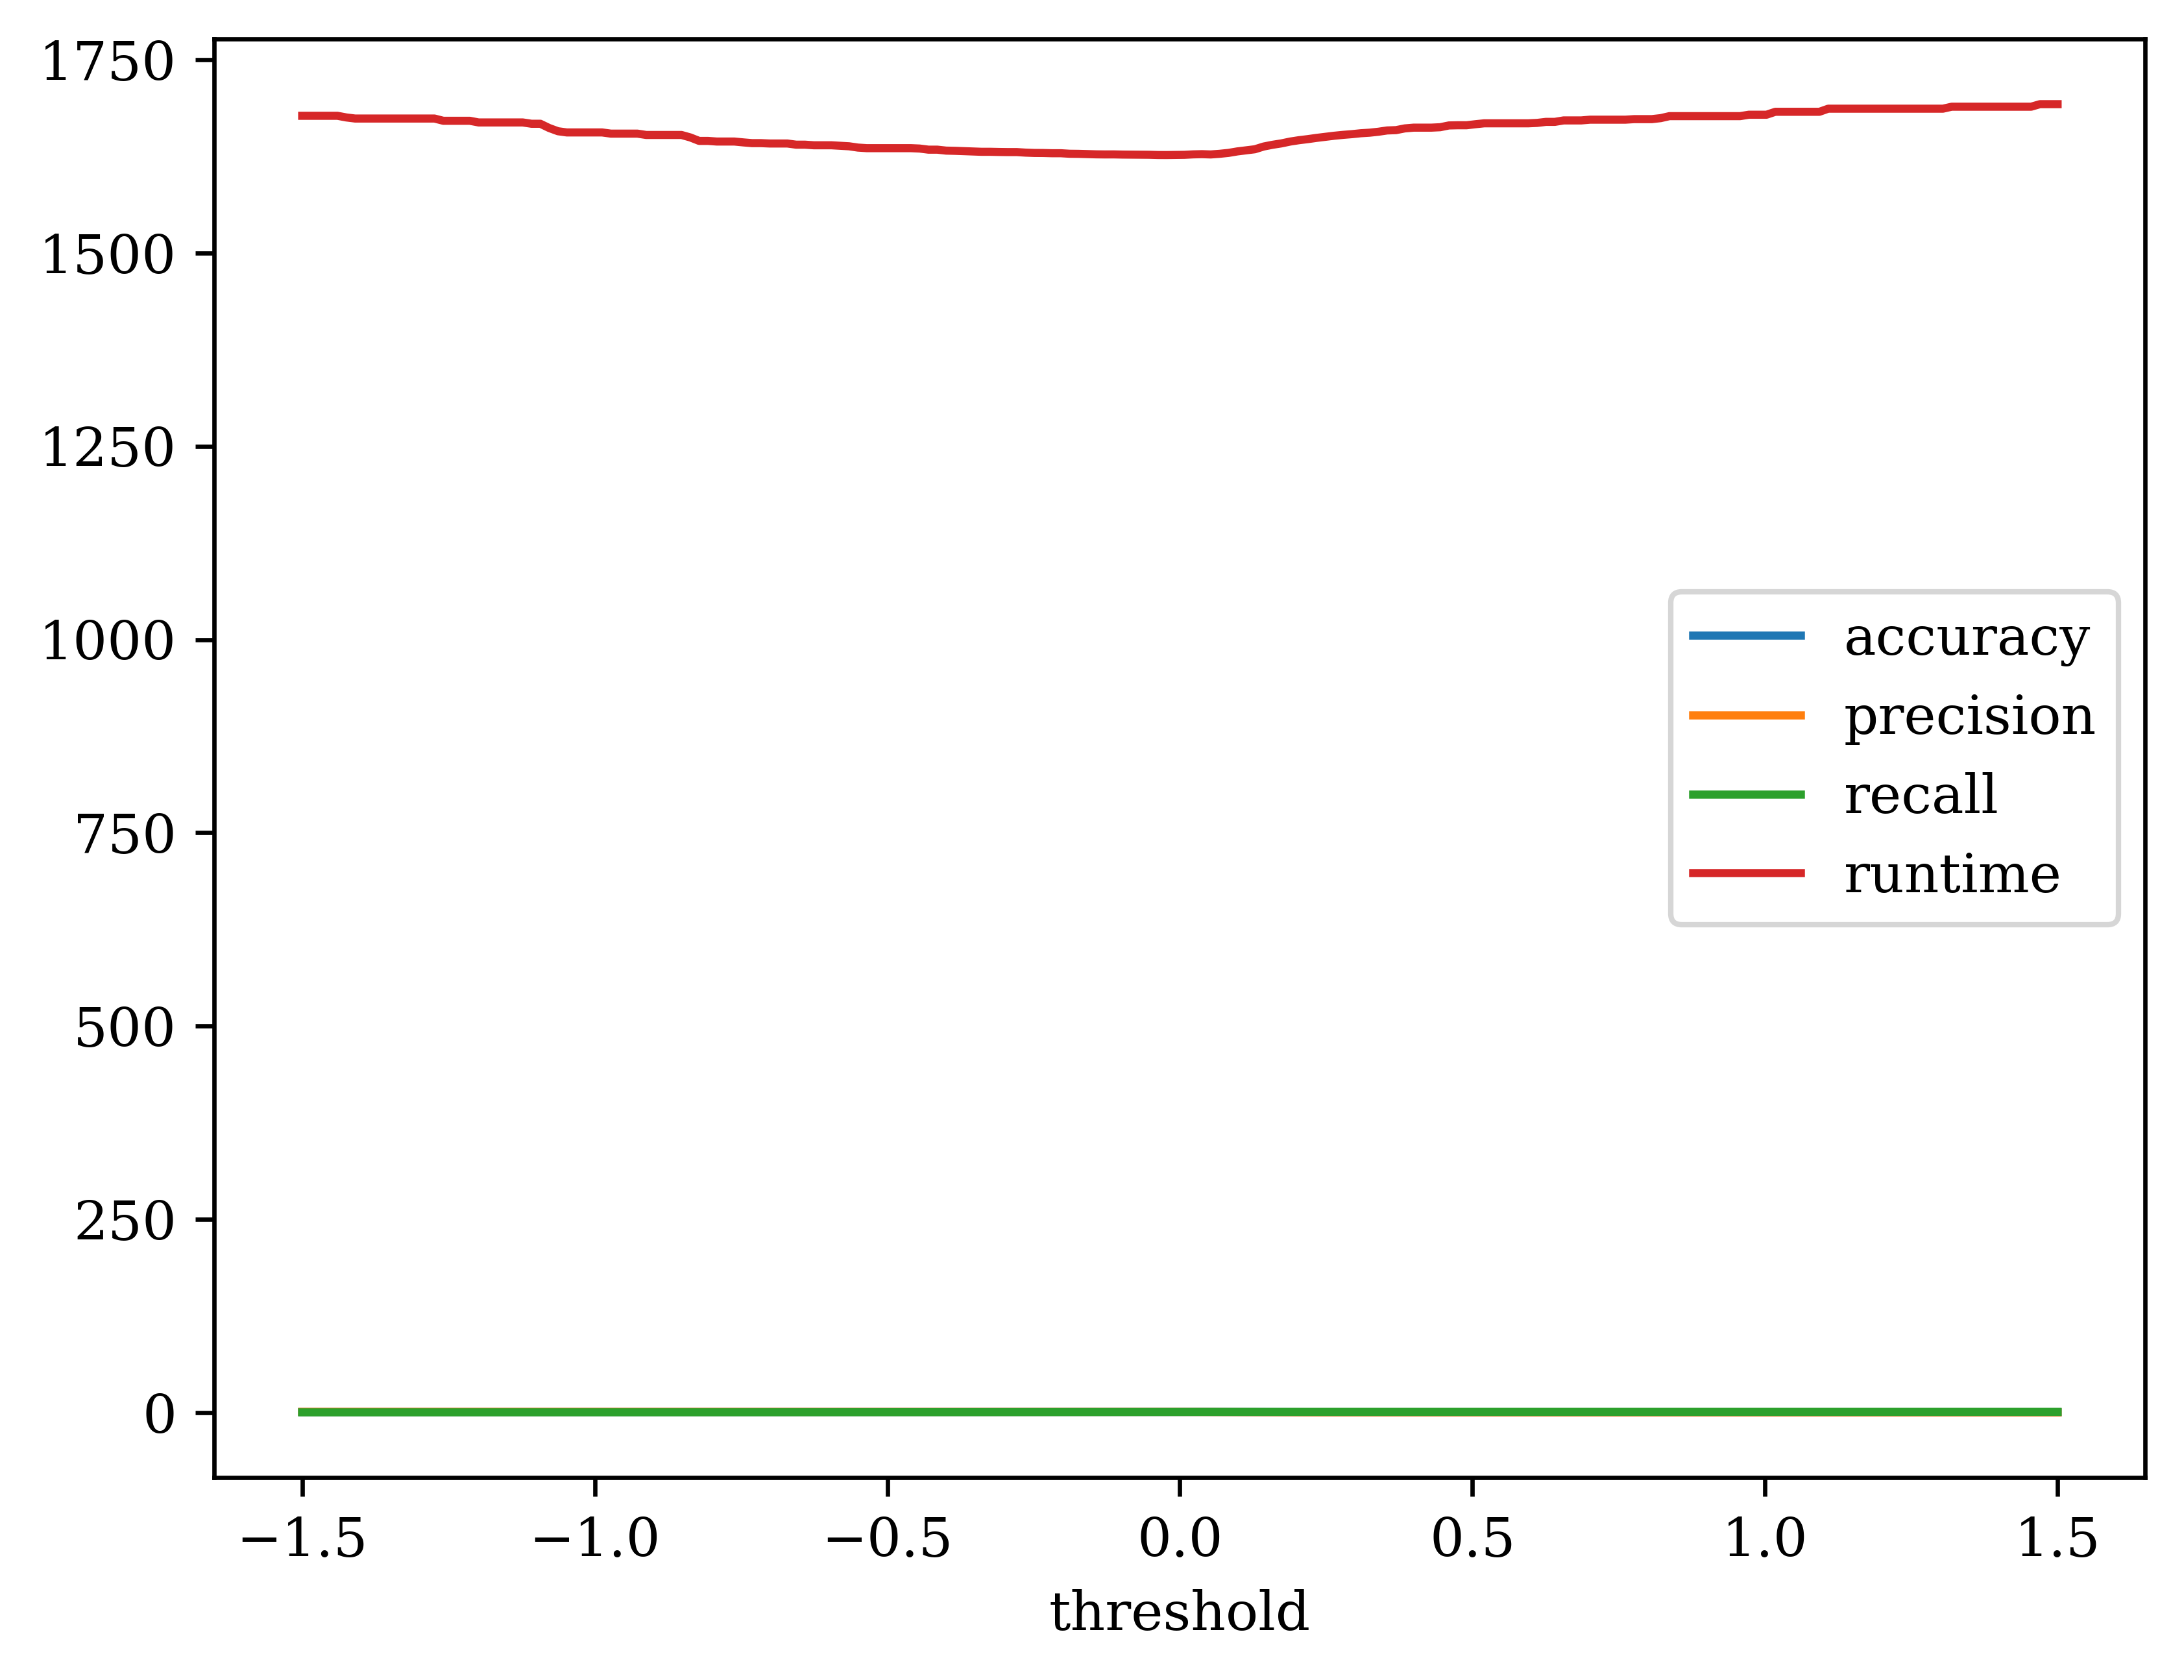

In [245]:
model = DecisionTreeRegressor(random_state = 20)
model.fit(X_train, y1_diff_log_train)
y1_pred_regr = model.predict(X_test)


mse = mean_squared_error(y1_diff_log_test, y1_pred_regr)
mae = mean_absolute_error(y1_diff_log_test, y1_pred_regr)
r2 = r2_score(y1_diff_log_test, y1_pred_regr)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

y1_pred_bin = (y1_pred_regr <= 0).astype(int)

evaluate_classifier(y1_test, y1_pred_bin)

thresholds = np.linspace(y1_pred_regr.min(), y1_pred_regr.max(), 30)
thresholds = np.linspace(-1.5, 1.5, 200)

def threshold_scores(th):
    y1_pred_bin = (y1_pred_regr <= th).astype(int)
    return (th,) + classifier_scores(y1_test, y1_pred_bin)

data = [threshold_scores(th) for th in thresholds]

df2 = pd.DataFrame(data, columns=['threshold', 'accuracy', 'precision', 'recall', 'runtime'])
#df2 = df2[['threshold', 'accuracy', 'precision', 'recall']]
#df2 = df2[['threshold', 'runtime']]

df2.plot.line(x='threshold')
plt.savefig('threshold-acc-prec-rec.eps')

In [197]:
y1_pred_regr_index = np.column_stack((y1_test.index, y1_pred_regr))
#y1_pred_regr_index

y1_pred_regr_df = pd.DataFrame(y1_pred_regr_index)
y1_pred_regr_df

,0,1
0,1466.0,0.925967
1,2841.0,-2.857744
2,2519.0,0.245999
3,2744.0,0.108893
4,2025.0,0.153985
...,...,...
433,1755.0,-0.106631
434,4505.0,-2.667284
435,1068.0,-1.238573
436,280.0,0.200739


In [148]:
pd.Series(y1_pred_regr, index=y1_test.index)

1863    0.131669
4075    2.089489
1884   -0.263313
3484    0.370275
4129    0.024825
          ...   
1903    0.178708
4219    0.010866
3335   -1.675069
2757   -0.308986
1029    0.222202
Length: 441, dtype: float64

## Analysis per benchmark

In [500]:
def runtimes(y1_test, y1_pred_dec_tree):
    test_set = df.loc[y1_test.index]
    test_set["decision"] = y1_pred_dec_tree
    test_set["decision runtime"] = np.where(
        (test_set["decision"] == 0), 
        test_set["orig(med)"], 
        test_set["rewr(med)"]
    )
    test_set["ideal runtime"] = np.where(
        (test_set["orig(med)"] < test_set["rewr(med)"]), 
        test_set["orig(med)"], 
        test_set["rewr(med)"]
    )
    orig_runtime_sum = test_set["orig(med)"].sum()
    decision_runtime_sum = test_set["decision runtime"].sum()
    ideal_runtime_sum = test_set["ideal runtime"].sum()
    rewritten_runtime_sum = test_set["rewr(med)"].sum()
    
    return (orig_runtime_sum, decision_runtime_sum, ideal_runtime_sum, rewritten_runtime_sum)

def analyse_bench(bench, _y1_pred_regr, _y1_diff_log_test, _y1_test):
    y1_pred_regr = _y1_pred_regr.loc[df["bench"] == bench]
    y1_diff_log_test = _y1_diff_log_test.loc[df["bench"] == bench]
    y1_test = _y1_test.loc[df["bench"] == bench]

    print(f"-- {bench} --\n")

    mse = mean_squared_error(y1_diff_log_test, y1_pred_regr)
    mae = mean_absolute_error(y1_diff_log_test, y1_pred_regr)
    r2 = r2_score(y1_diff_log_test, y1_pred_regr)

    print("count: " + str(len(y1_test)))

    print(f"MSE: {mse}")
    print(f"MAE: {mae}")

    y1_pred_bin = (y1_pred_regr <= 0).astype(int)
    evaluate_classifier(y1_test, y1_pred_bin)

    rt = runtimes(y1_test, y1_pred_bin)
    print("orig runtime: " + str(rt[0]))
    print("dec runtime: " + str(rt[1]))
    print("ideal runtime: " + str(rt[2]))
    print("rewritten runtime: " + str(rt[3]))
    
    print("\n")

y1_pred_regr_series = pd.Series(y1_pred_regr, index=y1_test.index)
for bench in ["HETIO", "STATS", "SNAP", "JOB", "LSQB"]:
    analyse_bench(bench, y1_pred_regr_series, y1_diff_log_test, y1_test)

-- HETIO --

count: 73
MSE: 0.014084054720405977
MAE: 0.06415178913526558
Accuracy: 0.9452054794520548
Precision: 0.9354838709677419
Recall: 0.9354838709677419
[[40  2]
 [ 2 29]]
orig runtime: 700.7673752307892
dec runtime: 192.0058102607727
ideal runtime: 191.8694303035736
rewritten runtime: 198.0106384754181


-- STATS --

count: 306
MSE: 0.00501523209030734
MAE: 0.038295854174618296
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Accuracy: 0.9477124183006536
Precision: 0.952
Recall: 0.9224806201550387
[[171   6]
 [ 10 119]]
orig runtime: 937.522652387619
dec runtime: 307.9485664367676
ideal runtime: 307.2482624053955
rewritten runtime: 335.4611849784851


-- SNAP --

count: 21
MSE: 0.0001590658766547949
MAE: 0.00389121191828797
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
[[ 1  0]
 [ 0 20]]
orig runtime: 1978.2465074062347
dec runtime: 730.5458943843842
ideal runtime: 730.5458943843

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `z

In [387]:
## example tradeoff 1

y1_pred_bin = (y1_pred_regr <= -0.05).astype(int)

scores = classifier_scores(y1_test, y1_pred_bin)
scores

(0.9387755102040817, 0.98125, 0.8674033149171271, 1262.8693158626556)

In [388]:
## example tradeoff 2

y1_pred_bin = (y1_pred_regr <= -0.34).astype(int)

scores = classifier_scores(y1_test, y1_pred_bin)
scores

(0.8344671201814059, 1.0, 0.5966850828729282, 1270.6522643566132)

In [389]:
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

In [390]:
# plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r"""
#         \usepackage{libertine}
#         \usepackage[libertine]{newtxmath}
#         """
# plt.rcParams['text.usetex'] = False

#plt.rcParams['text.latex.preview'] = True
#plt.rcParams['ps.usedistiller'] = 'xpdf'

training time: 0.001194000244140625
MSE: 0.02353447278225746
MAE: 0.05969583935941635
Accuracy: 0.9523809523809523
Precision: 0.9545454545454546
Recall: 0.9281767955801105
[[252   8]
 [ 13 168]]


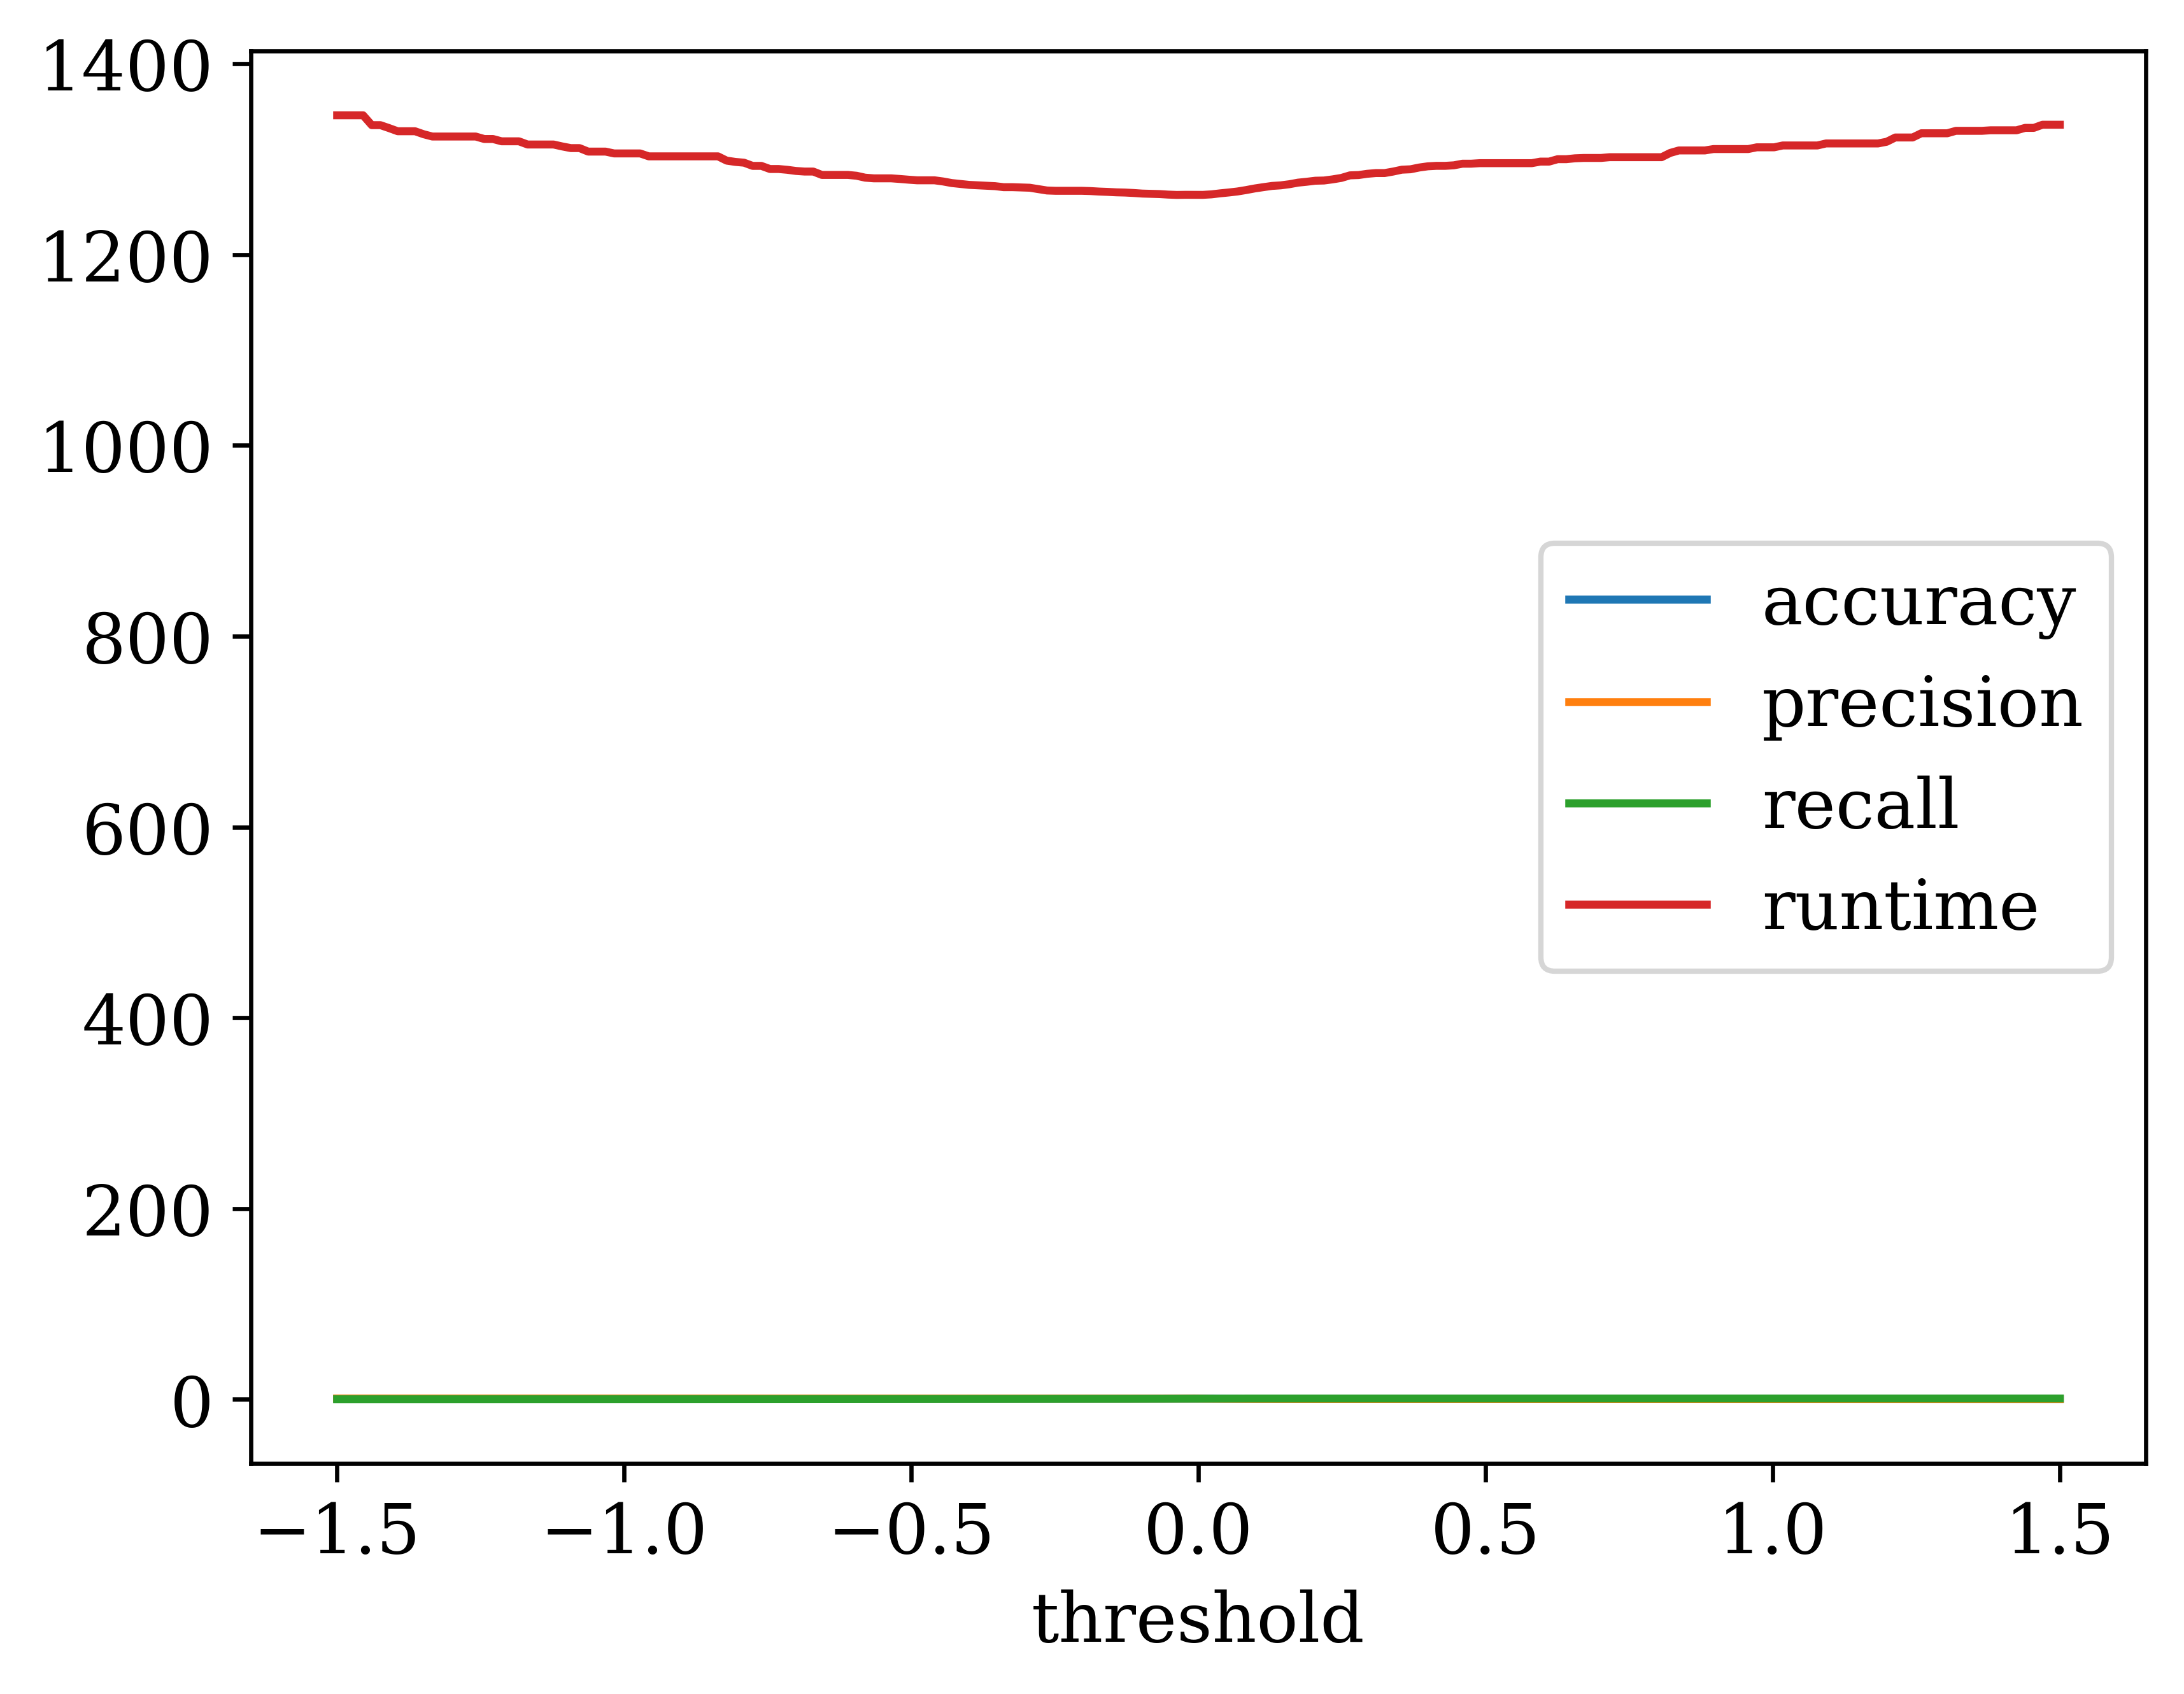

In [391]:
model = DecisionTreeRegressor(random_state = 20)
model.fit(X_train, y1_diff_log_train)

import time

t0 = time.time()

y1_pred_regr = model.predict(X_test)

t1 = time.time()

total = t1-t0

print("training time: " + str(total))

mse = mean_squared_error(y1_diff_log_test, y1_pred_regr)
mae = mean_absolute_error(y1_diff_log_test, y1_pred_regr)
r2 = r2_score(y1_diff_log_test, y1_pred_regr)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

y1_pred_bin = (y1_pred_regr <= 0).astype(int)

evaluate_classifier(y1_test, y1_pred_bin)

thresholds = np.linspace(y1_pred_regr.min(), y1_pred_regr.max(), 200)
#thresholds = np.linspace(-1.5, 1.5, 200)

def threshold_scores(th):
    y1_pred_bin = (y1_pred_regr <= th).astype(int)
    return (th,) + classifier_scores(y1_test, y1_pred_bin)

data = [threshold_scores(th) for th in thresholds]

df2 = pd.DataFrame(data, columns=['threshold', 'accuracy', 'precision', 'recall', 'runtime'])
#df2 = df2[['threshold', 'accuracy', 'precision', 'recall']]
#df2 = df2[['threshold', 'runtime', 'accuracy']]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'

plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots()
#fig.tight_layout()
#plt.figure()
df2[['threshold', 'runtime']].plot.line(ax=ax1, x='threshold', color={'runtime': 'lightseagreen'})
df2[['threshold', 'accuracy']].plot.line(ax=ax1, x='threshold', color={'accuracy': 'midnightblue'}, secondary_y=True)
df2[['threshold', 'precision']].plot.line(ax=ax1, x='threshold', color={'precision': 'coral'}, secondary_y=True)
#ax1.axvline(0, color='k', linestyle='--')

plt.savefig('threshold-e2e.pdf')

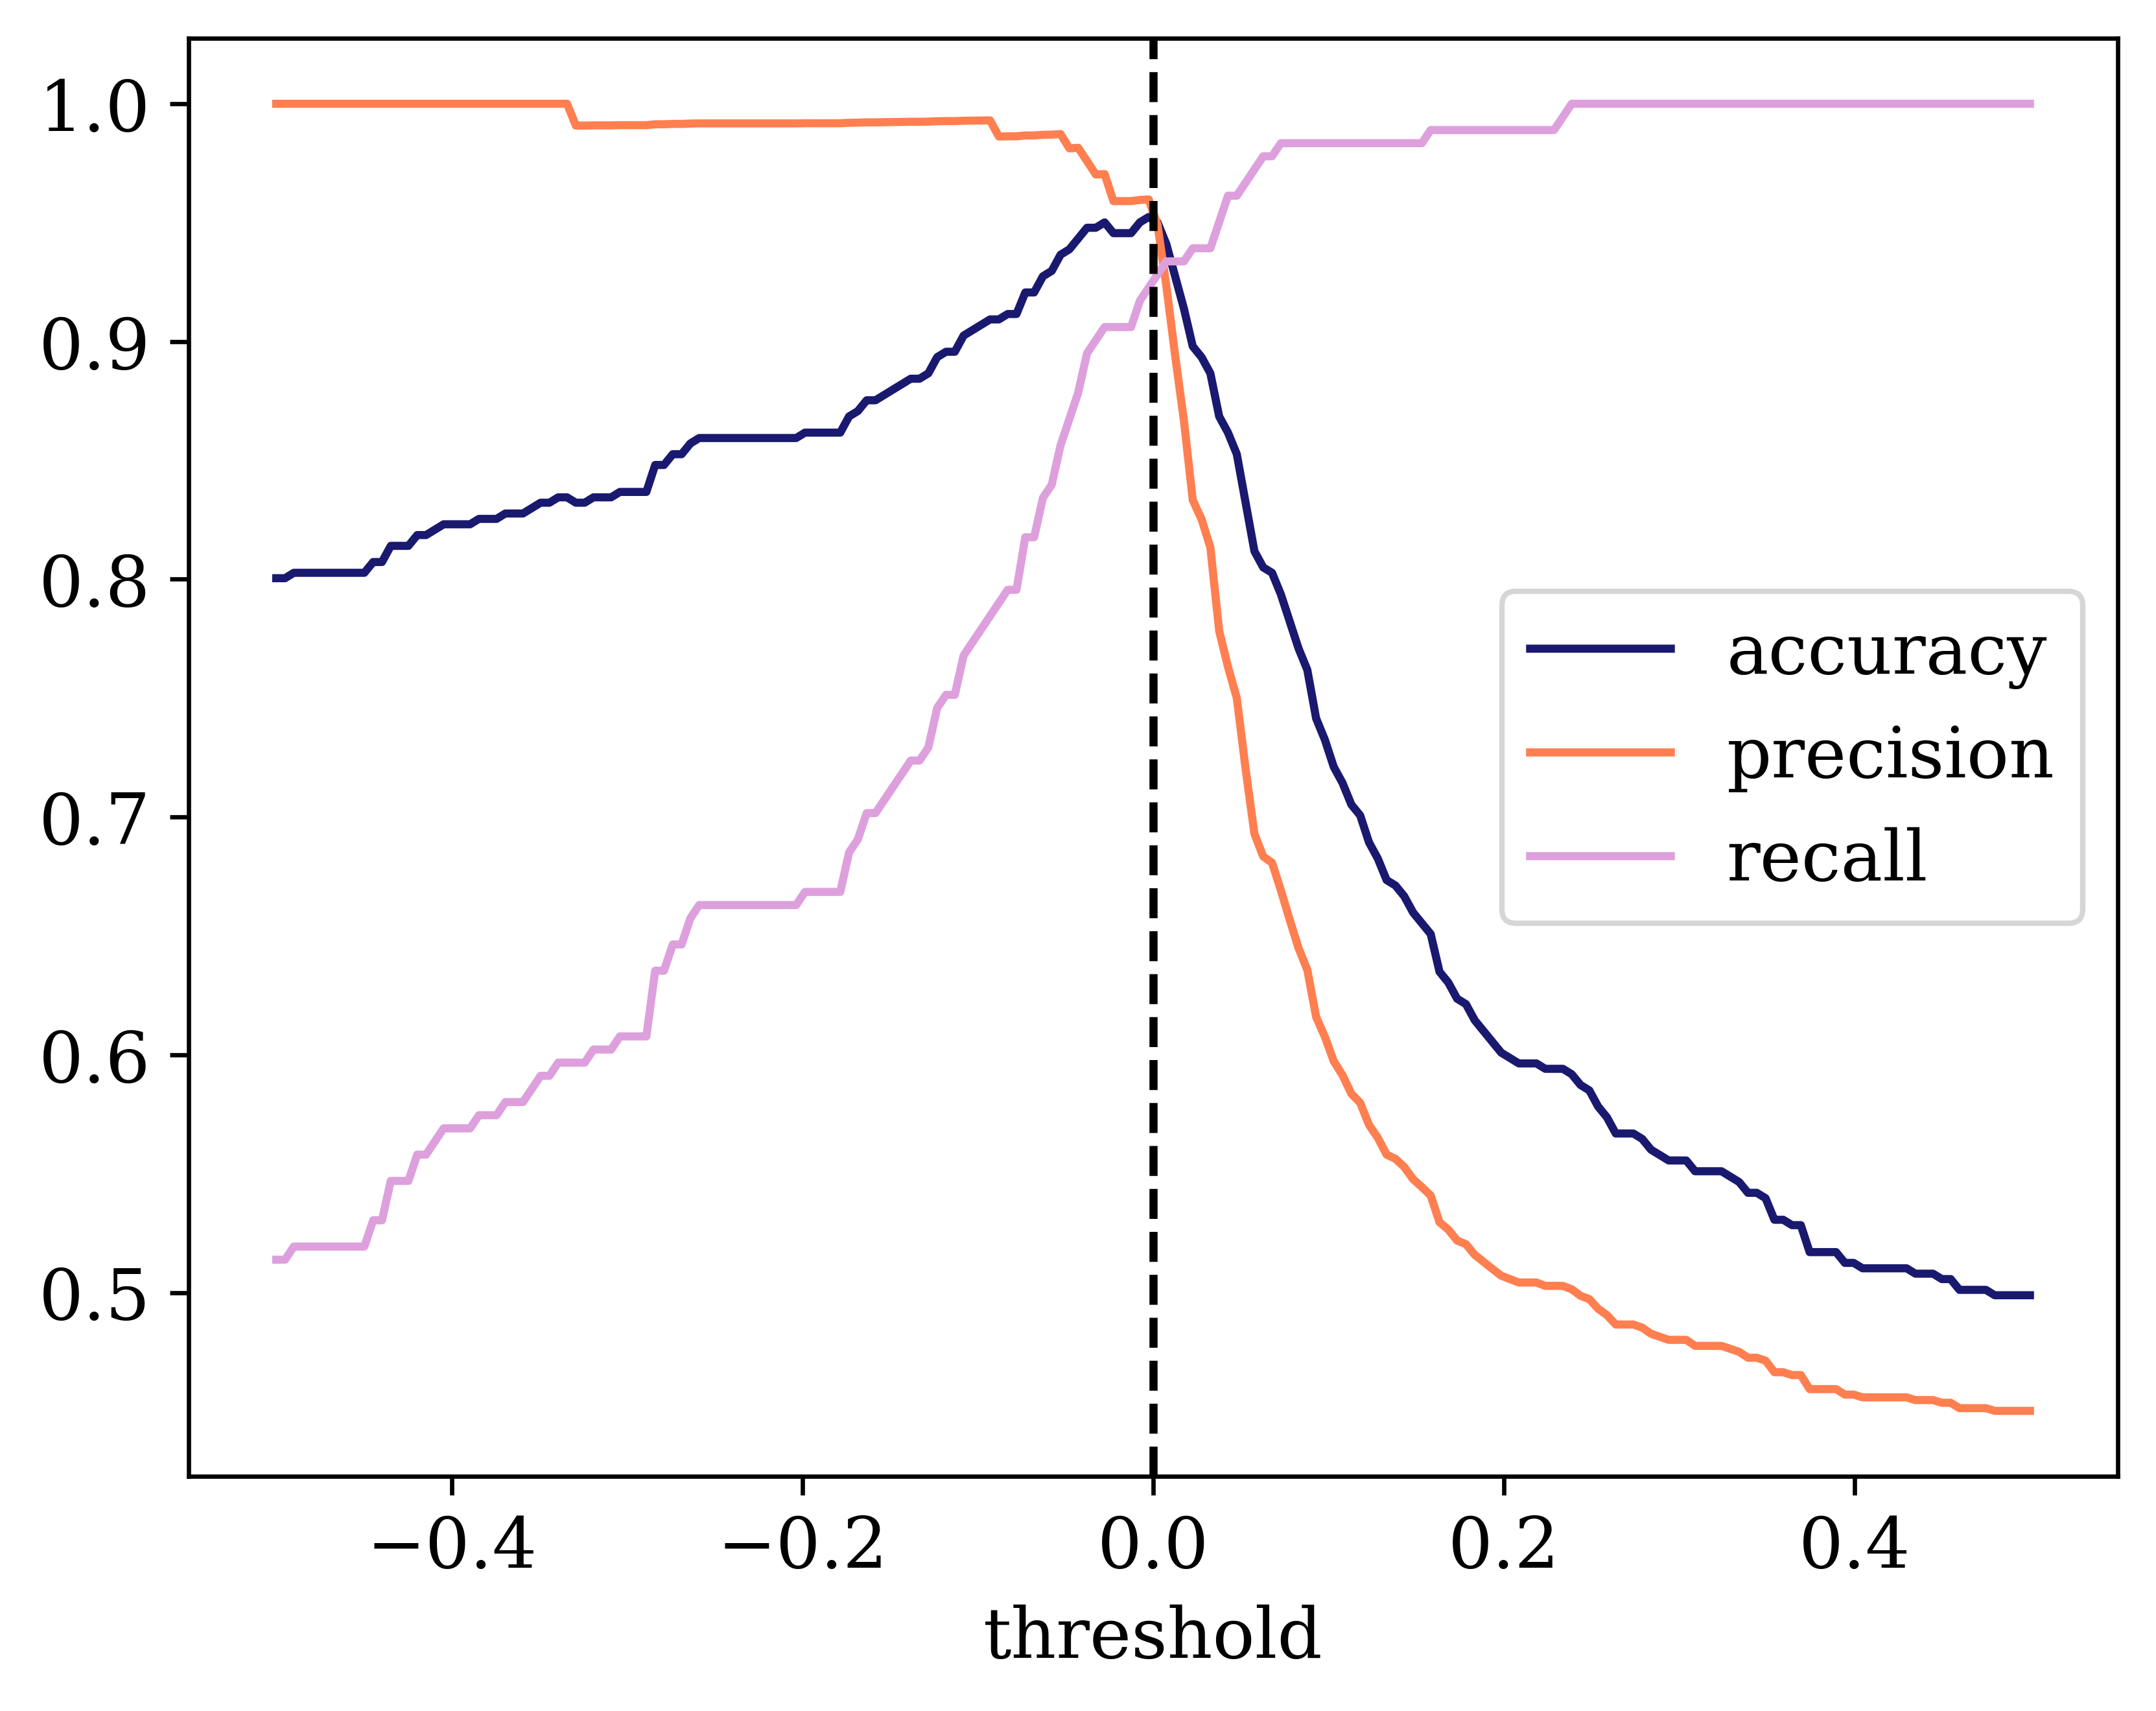

In [504]:
thresholds = np.linspace(-0.5, 0.5, 200)

def threshold_scores(th):
    y1_pred_bin = (y1_pred_regr <= th).astype(int)
    return (th,) + classifier_scores(y1_test, y1_pred_bin)

data = [threshold_scores(th) for th in thresholds]

df3 = pd.DataFrame(data, columns=['threshold', 'accuracy', 'precision', 'recall', 'runtime'])
df3 = df3[['threshold', 'accuracy', 'precision', 'recall']]

plt.rcParams.update({'font.size': 13})
#plt.tight_layout()

ax = df3.plot.line(x='threshold', color={'accuracy': 'midnightblue', 'precision': 'coral', 'recall': 'plum'})
ax.axvline(0, color='k', linestyle='--')
plt.show()
plt.savefig('threshold-acc-prec-rec.pdf')

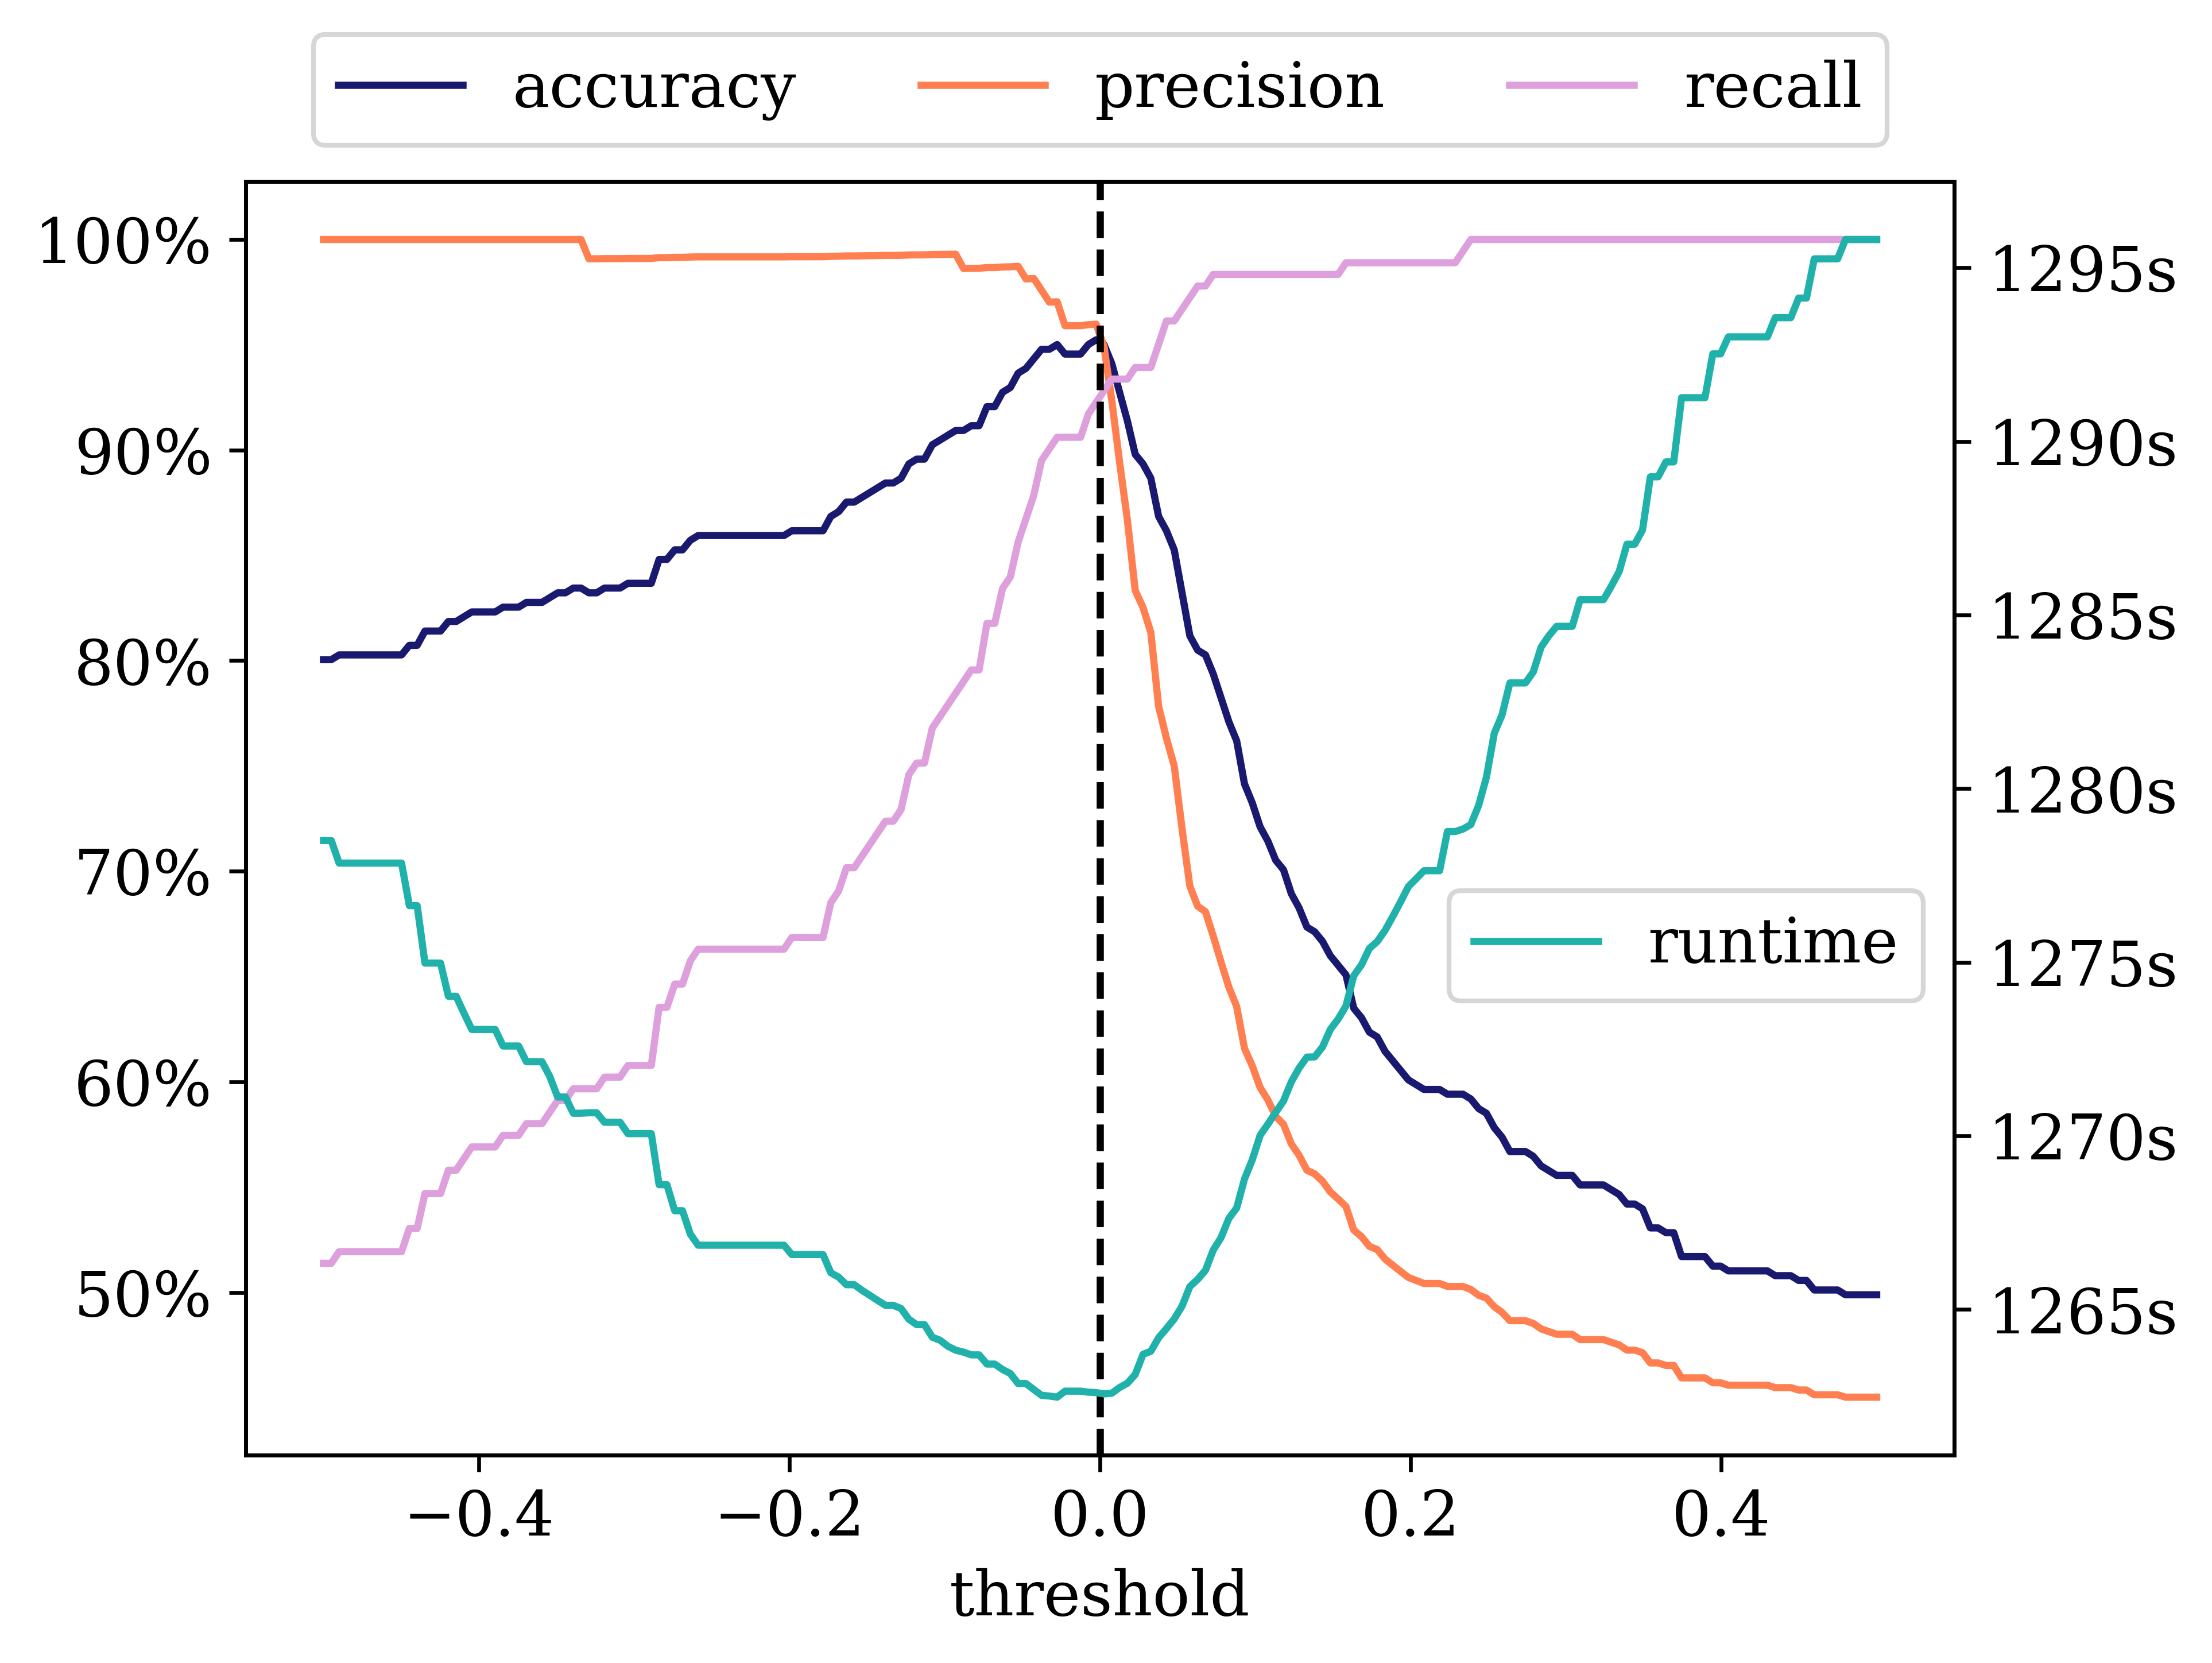

In [511]:
import matplotlib.ticker as mtick

thresholds = np.linspace(-0.5, 0.5, 200)

def threshold_scores(th):
    y1_pred_bin = (y1_pred_regr <= th).astype(int)
    return (th,) + classifier_scores(y1_test, y1_pred_bin)

data = [threshold_scores(th) for th in thresholds]

df3 = pd.DataFrame(data, columns=['threshold', 'accuracy', 'precision', 'recall', 'runtime'])
df4 = df3[['threshold', 'runtime']]
df3 = df3[['threshold', 'accuracy', 'precision', 'recall']]

plt.rcParams.update({'font.size': 13})
#plt.tight_layout()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
func = lambda x, pos: f"{x:.0f}s"
ax2.yaxis.set_major_formatter(func)

df3.plot.line(ax=ax1, x='threshold', color={'accuracy': 'midnightblue', 'precision': 'coral', 'recall': 'plum'})

#ax.legend(loc='upper center')
df4.plot.line(ax=ax2, x='threshold', color={'runtime': 'lightseagreen'})
ax1.axvline(0, color='k', linestyle='--')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)
ax2.legend(loc='center right',bbox_to_anchor=(1, 0.4),
          ncol=1, fancybox=True)
plt.savefig('threshold-all.pdf')
plt.show()

In [394]:
test_set = df.loc[y1_test.index]

In [395]:
y1_pred_0 = (y1_pred_regr <= 0).astype(int)
test_set["decision"] = y1_pred_0

In [396]:
test_set["ideal runtime"] = np.where(
    (test_set["orig/rewr(med)"] == "orig"), 
    test_set["orig(med)"], 
    test_set["rewr(med)"]
)

In [397]:
test_set["decision runtime"] = np.where(
    (test_set["decision"] == 0), 
    test_set["orig(med)"], 
    test_set["rewr(med)"]
)

In [398]:
test_set_0ma = test_set.loc[test_set["0ma"] == 1]

In [399]:
test_set_enum = test_set.loc[test_set["0ma"] == 0]

In [400]:
def get_summary(test_set):
    summary_data = {
    "orig": [
        test_set["orig(med)"].sum(),
        test_set["orig(med)"].mean(),
        test_set["orig(med)"].min(),
        test_set["orig(med)"].max(),
        test_set["orig(med)"].median(),
        test_set["orig(med)"].std()
    ],
    "rewr": [
        test_set["rewr(med)"].sum(),
        test_set["rewr(med)"].mean(),
        test_set["rewr(med)"].min(),
        test_set["rewr(med)"].max(),
        test_set["rewr(med)"].median(),
        test_set["rewr(med)"].std()
    ],
    "dec": [
        test_set["decision runtime"].sum(),
        test_set["decision runtime"].mean(),
        test_set["decision runtime"].min(),
        test_set["decision runtime"].max(),
        test_set["decision runtime"].median(),
        test_set["decision runtime"].std()
    ],
    "true": [
        test_set["ideal runtime"].sum(),
        test_set["ideal runtime"].mean(),
        test_set["ideal runtime"].min(),
        test_set["ideal runtime"].max(),
        test_set["ideal runtime"].median(),
        test_set["ideal runtime"].std()
    ]
    }
    return summary_data

summary_data = get_summary(test_set)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

,orig,rewr,dec,true
sum,3648.576329,1659.743299,1262.540065,1261.518195
mean,8.273416,3.763590,2.862903,2.860585
median,0.001049,0.010245,0.001049,0.001049
std,100.000000,93.405154,93.405154,93.405154
min,0.216564,0.221221,0.134570,0.131986
max,23.676707,12.234329,10.941051,10.941407


In [401]:
summary_data = get_summary(test_set_0ma)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

,orig,rewr,dec,true
sum,3123.724531,923.135185,759.735156,758.887401
mean,10.241720,3.026673,2.490935,2.488155
median,0.001049,0.010245,0.001049,0.001049
std,100.000000,93.405154,93.405154,93.405154
min,0.213658,0.162416,0.122948,0.122948
max,27.528904,12.391577,11.634764,11.635297


In [402]:
summary_data = get_summary(test_set_enum)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

,orig,rewr,dec,true
sum,524.851798,736.608114,502.804909,502.630793
mean,3.859204,5.416236,3.697095,3.695815
median,0.001526,0.017601,0.001526,0.001526
std,58.469130,55.835086,55.835086,55.835086
min,0.273993,0.600440,0.273993,0.273993
max,9.600494,11.751134,9.182217,9.181944


## Out of bounds data evaluation

In [431]:
y1_diff = df["diff rewr-orig"]
y1_diff_log = np.sign(y1_diff) * np.log(abs(y1_diff) +1)

def runtimes(y1_test, y1_pred_dec_tree):
    test_set = df.loc[y1_test.index]
    test_set["decision"] = y1_pred_dec_tree
    test_set["decision runtime"] = np.where(
        (test_set["decision"] == 0), 
        test_set["orig(med)"], 
        test_set["rewr(med)"]
    )
    orig_runtime_sum = test_set["orig(med)"].sum()
    decision_runtime_sum = test_set["decision runtime"].sum()
    
    return (orig_runtime_sum, decision_runtime_sum)

def split_on_benchmark(X, y1, y1_diff, name):
    return (X.loc[df["bench"] != name], y1.loc[df["bench"] != name], y1_diff.loc[df["bench"] != name],
            X.loc[(df["bench"] == name) & (df["is_base"] == True)],
            y1.loc[(df["bench"] == name) & (df["is_base"] == True)],
            y1_diff.loc[(df["bench"] == name) & (df["is_base"] == True)])

def oob_eval(benchmark, thresh):
    print(f"-- {benchmark} --\n")
    X_train, y1_train, y1_diff_train, X_test, y1_test, y1_diff_test = split_on_benchmark(X, y1, y1_diff_log, benchmark)

    model = DecisionTreeRegressor(random_state = 20)
    model.fit(X_train, y1_diff_train)

    y1_pred_regr = model.predict(X_test)

    mse = mean_squared_error(y1_diff_test, y1_pred_regr)
    mae = mean_absolute_error(y1_diff_test, y1_pred_regr)
    r2 = r2_score(y1_diff_test, y1_pred_regr)

    print(f"MSE: {mse}")
    print(f"MAE: {mae}")

    y1_pred_bin = (y1_pred_regr <= thresh).astype(int)

    evaluate_classifier(y1_test, y1_pred_bin)
    rt = runtimes(y1_test, y1_pred_bin)
    print("orig runtime: " + str(rt[0]))
    print("dec runtime: " + str(rt[1]))

    print("\n")

    return rt[0] / rt[1]

def oob_all(thresh):
    return (thresh,
    oob_eval("HETIO", thresh),
    oob_eval("STATS", thresh),
    oob_eval("SNAP", thresh),
    oob_eval("JOB", thresh),
    oob_eval("LSQB", thresh))

thresholds = np.linspace(-3.5, 0.5, 120)
data = [oob_all(th) for th in thresholds]
df_oob = pd.DataFrame(data, columns=['threshold', 'hetio', 'stats', 'snap', 'job', 'lsqb'])
df_oob.plot.line(x='threshold')
plt.savefig("oob-e2e.pdf")
plt.show()

-- HETIO --

MSE: 6.067977186025815
MAE: 1.7577627778959826
Accuracy: 0.7253218884120172
Precision: 1.0
Recall: 0.13513513513513514
[[159   0]
 [ 64  10]]
orig runtime: 1602.9658963680267
dec runtime: 1441.2291269302368


-- STATS --

MSE: 2.0357677032194514
MAE: 1.2142137951185146
Accuracy: 0.7048872180451128
Precision: 0.7333333333333333
Recall: 0.06707317073170732
[[364   4]
 [153  11]]
orig runtime: 2530.555100440979
dec runtime: 2438.7129414081573


-- SNAP --

MSE: 1.3488148605747958
MAE: 0.7128188296978297
Accuracy: 0.7894736842105263
Precision: 1.0
Recall: 0.7714285714285715
[[ 3  0]
 [ 8 27]]
orig runtime: 3196.651359796524
dec runtime: 1636.2066853046417


-- JOB --

MSE: 9.85853590976996
MAE: 2.4719300983298758
Accuracy: 0.95
Precision: 0.0
Recall: 0.0
[[57  0]
 [ 3  0]]
orig runtime: 67.21803307533264
dec runtime: 67.21803307533264


-- LSQB --



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MSE: 25.771523012942943
MAE: 4.283082742093488
Accuracy: 0.2
Precision: 0.25
Recall: 0.5
[[0 3]
 [1 1]]
orig runtime: 142.57186484336853
dec runtime: 65.09597539901733


-- HETIO --

MSE: 6.067977186025815
MAE: 1.7577627778959826
Accuracy: 0.7253218884120172
Precision: 1.0
Recall: 0.13513513513513514
[[159   0]
 [ 64  10]]
orig runtime: 1602.9658963680267
dec runtime: 1441.2291269302368


-- STATS --

MSE: 2.0357677032194514
MAE: 1.2142137951185146
Accuracy: 0.7048872180451128
Precision: 0.7333333333333333
Recall: 0.06707317073170732
[[364   4]
 [153  11]]
orig runtime: 2530.555100440979
dec runtime: 2438.7129414081573


-- SNAP --

MSE: 1.3488148605747958
MAE: 0.7128188296978297
Accuracy: 0.7894736842105263
Precision: 1.0
Recall: 0.7714285714285715
[[ 3  0]
 [ 8 27]]
orig runtime: 3196.651359796524
dec runtime: 1636.2066853046417


-- JOB --

MSE: 9.85853590976996
MAE: 2.4719300983298758
Accuracy: 0.95
Precision: 0.0
Recall: 0.0
[[57  0]
 [ 3  0]]
orig runtime: 67.21803307533264
dec r

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MSE: 25.771523012942943
MAE: 4.283082742093488
Accuracy: 0.2
Precision: 0.25
Recall: 0.5
[[0 3]
 [1 1]]
orig runtime: 142.57186484336853
dec runtime: 65.09597539901733


-- HETIO --

MSE: 6.067977186025815
MAE: 1.7577627778959826
Accuracy: 0.7253218884120172
Precision: 1.0
Recall: 0.13513513513513514
[[159   0]
 [ 64  10]]
orig runtime: 1602.9658963680267
dec runtime: 1441.2291269302368


-- STATS --

MSE: 2.0357677032194514
MAE: 1.2142137951185146
Accuracy: 0.7048872180451128
Precision: 0.7333333333333333
Recall: 0.06707317073170732
[[364   4]
 [153  11]]
orig runtime: 2530.555100440979
dec runtime: 2438.7129414081573


-- SNAP --

MSE: 1.3488148605747958
MAE: 0.7128188296978297
Accuracy: 0.7894736842105263
Precision: 1.0
Recall: 0.7714285714285715
[[ 3  0]
 [ 8 27]]
orig runtime: 3196.651359796524
dec runtime: 1636.2066853046417


-- JOB --

MSE: 9.85853590976996
MAE: 2.4719300983298758
Accuracy: 0.95
Precision: 0.0
Recall: 0.0
[[57  0]
 [ 3  0]]
orig runtime: 67.21803307533264
dec r

...

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MSE: 9.85853590976996
MAE: 2.4719300983298758
Accuracy: 0.95
Precision: 0.0
Recall: 0.0
[[57  0]
 [ 3  0]]
orig runtime: 67.21803307533264
dec runtime: 67.21803307533264


-- LSQB --

MSE: 25.771523012942943
MAE: 4.283082742093488
Accuracy: 0.2
Precision: 0.25
Recall: 0.5
[[0 3]
 [1 1]]
orig runtime: 142.57186484336853
dec runtime: 65.09597539901733


-- HETIO --

MSE: 6.067977186025815
MAE: 1.7577627778959826
Accuracy: 0.5536480686695279
Precision: 0.3469387755102041
Recall: 0.4594594594594595
[[95 64]
 [40 34]]
orig runtime: 1602.9658963680267
dec runtime: 1349.1510088443756


-- STATS --

MSE: 2.0357677032194514
MAE: 1.2142137951185146
Accuracy: 0.7368421052631579
Precision: 0.875
Recall: 0.17073170731707318
[[364   4]
 [136  28]]
orig runtime: 2530.555100440979
dec runtime: 2266.1776599884033


-- SNAP --

MSE: 1.3488148605747958
MAE: 0.7128188296978297
Accuracy: 0.7894736842105263
Precision: 1.0
Recall: 0.7714285714285715
[[ 3  0]
 [ 8 27]]
orig runtime: 3196.651359796524
dec runt

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MSE: 6.067977186025815
MAE: 1.7577627778959826
Accuracy: 0.5364806866952789
Precision: 0.3333333333333333
Recall: 0.4594594594594595
[[91 68]
 [40 34]]
orig runtime: 1602.9658963680267
dec runtime: 1350.2653563022614


-- STATS --

MSE: 2.0357677032194514
MAE: 1.2142137951185146
Accuracy: 0.7368421052631579
Precision: 0.875
Recall: 0.17073170731707318
[[364   4]
 [136  28]]
orig runtime: 2530.555100440979
dec runtime: 2266.1776599884033


-- SNAP --

MSE: 1.3488148605747958
MAE: 0.7128188296978297
Accuracy: 0.7894736842105263
Precision: 1.0
Recall: 0.7714285714285715
[[ 3  0]
 [ 8 27]]
orig runtime: 3196.651359796524
dec runtime: 1636.2066853046417


-- JOB --

MSE: 9.85853590976996
MAE: 2.4719300983298758
Accuracy: 0.9333333333333333
Precision: 0.0
Recall: 0.0
[[56  1]
 [ 3  0]]
orig runtime: 67.21803307533264
dec runtime: 69.83256816864014


-- LSQB --

MSE: 25.771523012942943
MAE: 4.283082742093488
Accuracy: 0.2
Precision: 0.25
Recall: 0.5
[[0 3]
 [1 1]]
orig runtime: 142.5718648433

<Axes: xlabel='threshold'>

In [413]:
df[(df["bench"] == "JOB") & (df["is_base"] == True)]

,bench,query,orig/rewr(med),orig(med),rewr(med),0ma,#relations,#conditions,#filters,#joins,...,q75(container counts),min(branching factors),max(branching factors),mean(branching factors),median(branching factors),q25(branching factors),q75(branching factors),hypergraph,is_base,diff rewr-orig
1384,JOB,2a-full1,orig,0.535697,2.059083,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.523386
1385,JOB,2a-full2,orig,0.544196,2.040092,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.495896
1386,JOB,2a-full3,orig,0.534698,2.047565,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.512866
1393,JOB,2b-full1,orig,0.547952,2.061880,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.513927
1394,JOB,2b-full2,orig,0.530612,2.015038,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.484426
1395,JOB,2b-full3,orig,0.532190,2.051078,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.518888
1402,JOB,2c-full1,orig,0.526046,1.861151,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.335106
1403,JOB,2c-full2,orig,0.518114,1.857126,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.339012
1404,JOB,2c-full3,orig,0.517827,1.865309,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,1.347482
1411,JOB,2d-full1,orig,0.400183,3.130348,0,5,7,2,5,...,1.0,1,3,2.000000,2.0,1.50,2.50,"Hypergraph(num_v=30, num_e=5)",True,2.730165


## Random forest training

In [329]:
clf = RandomForestClassifier(n_estimators=100, random_state=20)
clf.fit(X_train, y1_train)
y1_pred_dec_tree = clf.predict(X_test)

In [330]:
evaluate_classifier(y1_test, y1_pred_dec_tree)

Accuracy: 0.9523809523809523
Precision: 0.9545454545454546
Recall: 0.9281767955801105
[[252   8]
 [ 13 168]]


### Regression

In [331]:
model = RandomForestRegressor(n_estimators=100, random_state=20)
model.fit(X_train, y1_diff_log_train)
y1_pred_regr = model.predict(X_test)


mse = mean_squared_error(y1_diff_log_test, y1_pred_regr)
mae = mean_absolute_error(y1_diff_log_test, y1_pred_regr)
r2 = r2_score(y1_diff_log_test, y1_pred_regr)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

y1_pred_bin = (y1_pred_regr <= 0).astype(int)

evaluate_classifier(y1_test, y1_pred_bin)

MSE: 0.03143581611196597
MAE: 0.07625410109996508
Accuracy: 0.9478458049886621
Precision: 0.9388888888888889
Recall: 0.9337016574585635
[[249  11]
 [ 12 169]]


### kNN training

In [332]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y1_train)
y1_pred_dec_tree = clf.predict(X_test)

In [333]:
evaluate_classifier(y1_test, y1_pred_dec_tree)

Accuracy: 0.9183673469387755
Precision: 0.8918918918918919
Recall: 0.9116022099447514
[[240  20]
 [ 16 165]]


### Regression

In [334]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y1_diff_log_train)
y1_pred_knn = model.predict(X_test)


mse = mean_squared_error(y1_diff_log_test, y1_pred_knn)
mae = mean_absolute_error(y1_diff_log_test, y1_pred_knn)
r2 = r2_score(y1_diff_log_test, y1_pred_knn)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

y1_pred_knn = model.predict(X_test)
y1_pred_bin = (y1_pred_knn <= 0).astype(int)

evaluate_classifier(y1_test, y1_pred_bin)

MSE: 0.17450206134245383
MAE: 0.17527709619965698
Accuracy: 0.909297052154195
Precision: 0.8770053475935828
Recall: 0.9060773480662984
[[237  23]
 [ 17 164]]


## SVM training

In [335]:
# runs forever
#clf = SVC(kernel='linear')
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(X_train, y1_train)
y1_pred_dec_tree = clf.predict(X_test)

evaluate_classifier(y1_test, y1_pred_dec_tree)

Accuracy: 0.8299319727891157
Precision: 0.8045977011494253
Recall: 0.7734806629834254
[[226  34]
 [ 41 140]]


### Regression

In [336]:
model = LinearSVR(random_state=0, tol=1e-5)
model.fit(X_train, y1_diff_log_train)
y1_pred_knn = model.predict(X_test)


mse = mean_squared_error(y1_diff_log_test, y1_pred_knn)
mae = mean_absolute_error(y1_diff_log_test, y1_pred_knn)
r2 = r2_score(y1_diff_log_test, y1_pred_knn)

print(f"MSE: {mse}")
print(f"MAE: {mae}")

y1_pred_knn = model.predict(X_test)
y1_pred_bin = (y1_pred_knn <= 0).astype(int)

evaluate_classifier(y1_test, y1_pred_bin)

MSE: 1.0255026275048984
MAE: 0.6085809142227927
Accuracy: 0.7913832199546486
Precision: 0.7602339181286549
Recall: 0.7182320441988951
[[219  41]
 [ 51 130]]


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### MLP training

In [ ]:
n_inputs = 30

class MLPClassifier(nn.Module):
    def __init__(self, random_seed=None):
        super().__init__()
        
        if random_seed is not None:
            torch.manual_seed(random_seed)
        
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 2)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.values).float()  # Convert DataFrame to tensor
        self.y = torch.from_numpy(y.values).float()  # Convert DataFrame to tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

def MLP_classification(X_training, y_training, X_validation, y_validation, type, text):
    custom_dataset = CustomDataset(X_training, y_training)
    trainloader = DataLoader(custom_dataset, batch_size=100, shuffle=True)

    mlp = MLPClassifier(random_seed=20)

    loss_function = nn.CrossEntropyLoss()  
        
    optimizer = torch.optim.Adagrad(mlp.parameters(), lr=0.1)

    val_data = torch.tensor(X_validation.values, dtype=torch.float32)
    val_targets = torch.tensor(y_validation.values, dtype=torch.float32)
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(300):
        print(f'Starting Epoch {epoch+1}')
    
        current_loss = 0.0
    
        for i, data in enumerate(trainloader, 0):
            inputs, targets = data
    
            optimizer.zero_grad()
    
            outputs = mlp(inputs)
    
            targets = targets.long()  # Convert target tensor to torch.long data type
            loss = loss_function(outputs, targets)
    
            loss.backward()
    
            optimizer.step()
    
            current_loss += loss.item()
    
        print(current_loss/len(trainloader))
    
        mlp.eval()
        with torch.no_grad():
            val_outputs = mlp(val_data).squeeze()
            val_targets = val_targets.long()
            val_loss = loss_function(val_outputs, val_targets).item()
            #print(f'Validation loss: {val_loss}')
    
        # Check if this is the best model so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = deepcopy(mlp.state_dict())
            print(f'New best model found at epoch {epoch+1} with validation loss {best_val_loss}')
    
    print("Training has completed")


    mlp2 = MLPClassifier(random_seed=20)
    mlp2.load_state_dict(best_model_state)
    
    mlp2.eval() 
    
    with torch.no_grad():
        outputs = mlp2(val_data).squeeze()
        predicted_labels = torch.argmax(outputs, dim=1).numpy()
    
    predicted_labels = np.array(predicted_labels)
    val_targets = np.array(val_targets)

    if type == "2_class":
        accuracy = accuracy_score(val_targets, predicted_labels)
        precision = precision_score(val_targets, predicted_labels)
        recall = recall_score(val_targets, predicted_labels)
        conf_matrix = confusion_matrix(val_targets, predicted_labels)
        conf_matrix

        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")

        cfd = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
        cfd.plot()
        plt.show()

In [ ]:
MLP_classification(X_train, y1_train, X_val, y1_val, "2_class", "MLP: 30-60-40-2")

## Regression

In [ ]:
def MLP_regression(X_training, y_training, X_validation, y_validation, text):
    custom_dataset = CustomDataset(X_training, y_training)
    trainloader = torch.utils.data.DataLoader(custom_dataset, batch_size=100, shuffle=False)

    mlp = MLP(random_seed=20)
    
    loss_function = torch.nn.MSELoss()
    optimizer = torch.optim.Adagrad(mlp.parameters(), lr=0.01)
    
    val_data = torch.tensor(X_validation.values, dtype=torch.float32)
    val_targets = torch.tensor(y_validation.values, dtype=torch.float32)
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(0,300):
        print(f'Starting Epoch {epoch+1}')
    
        current_loss = 0.0
    
        for i, data in enumerate(trainloader, 0):
            inputs, targets = data
            inputs, targets = inputs.float(), targets.float()
            targets = targets.reshape((targets.shape[0], 1))
    
            optimizer.zero_grad()
    
            outputs = mlp(inputs)
    
            loss = loss_function(outputs, targets)
    
            loss.backward()
    
            optimizer.step()
    
            current_loss += loss.item()
    
        print(current_loss/len(trainloader))
    
        mlp.eval()
        with torch.no_grad():
            val_outputs = mlp(val_data)
            val_loss = loss_function(val_outputs, val_targets.reshape(val_targets.shape[0], 1)).item()
            print(f'Validation loss: {val_loss}')
            print("mse", mean_squared_error(np.array(val_targets), np.array(val_outputs.squeeze().tolist())))
    
        # Check if this is the best model so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = deepcopy(mlp.state_dict())
            print(f'New best model found at epoch {epoch+1} with validation loss {best_val_loss}')
    
    
    print("Training has completed")

    mlp2 = MLP(random_seed=20)
    mlp2.load_state_dict(best_model_state)

    mlp2.eval() 
    
    with torch.no_grad():
        outputs = mlp2(val_data)
        predicted_labels = outputs.squeeze().tolist()
    
    predicted_labels = np.array(predicted_labels)
    val_targets = np.array(val_targets)
    
    mse = mean_squared_error(val_targets, predicted_labels)
    mae = mean_absolute_error(val_targets, predicted_labels)
    r2 = r2_score(val_targets, predicted_labels)
    print(f"MSE: {mse}")
    print(f"MAE: {mae}")
    
    y1_pred_bin = (predicted_labels <= 0).astype(int)
    evaluate_classifier(y1_val, y1_pred_bin)

In [ ]:
n_inputs = 30

class MLP(nn.Module):
    def __init__(self, random_seed=None):
        super().__init__()
        
        if random_seed is not None:
            torch.manual_seed(random_seed)
        
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
MLP_regression(X_train, y1_diff_log_train, X_val, y1_diff_log_val, "MLP: 30-60-40-2")

### HGNN training

In [ ]:
#X_hg = pd.concat([X, df.iloc[:,44]], axis = 1)
X_hg = df.iloc[:, 5:-1]
X_train_hg = X_hg.loc[X_train.index]
X_val_hg = X_hg.loc[X_val.index]
X_test_hg = X_hg.loc[X_test.index]

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, label_series, hypergraph_column_name):
        # Extract features and convert to tensor
        self.X = torch.from_numpy(dataframe.drop(columns=[hypergraph_column_name]).values).float()
        
        # Extract labels and convert to tensor
        self.y = torch.from_numpy(label_series.values).float()
        
        # Store hypergraph objects
        self.hypergraphs = dataframe[hypergraph_column_name].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return {
            'data': self.X[index],
            'label': self.y[index],
            'hypergraph': self.hypergraphs[index]
        }

In [ ]:
class HGNN(nn.Module):
    def __init__(self, random_seed = None):
        super().__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))  

        self.fc1 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) 

        output = self.fc1(x)
        return output.squeeze()

In [ ]:
def HGNN_classification(X_training, y_training, X_validation, y_validation, type, text):
    model = HGNN(random_seed = 20)  

    dataset = CustomDataset(X_training, y_training, hypergraph_column_name='hypergraph')
    validation = CustomDataset(X_validation, y_validation, hypergraph_column_name='hypergraph')
    
    # Loss function and optimizer
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    num_epochs = 100
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for item in dataset:
            optimizer.zero_grad()
            input_features = item["data"]
            input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
            label = item["label"].long()
            output = model(input_hg)
            
            loss = loss_function(output, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataset):.4f}')
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for item in validation:
                input_features = item["data"]
                input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
                label = item["label"].long()
                output = model(input_hg)
                loss = loss_function(output, label)
                val_loss += loss.item()
    
        val_loss /= len(validation)
        print(f'Validation Loss: {val_loss:.4f}')
    
        # Save the model if the validation loss is the best we've seen so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Saved the best model with validation loss: {val_loss:.4f}')
    
    
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    predicted = []
    with torch.no_grad():
        i = 0
        for item in validation:
            i += 1
            output = model(item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0))
            _, pred = torch.max(output.data, 0)
            predicted.append(pred.item())

    if type == "2_class":
        accuracy = accuracy_score(y_validation, predicted)
        recall = recall_score(y_validation, predicted)
        conf_matrix = confusion_matrix(y_validation, predicted)
        conf_matrix
        precision = precision_score(y_validation, predicted)

        cfd = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
        cfd.plot()
        plt.show()

        

In [ ]:
class HGNN(nn.Module):
    def __init__(self, random_seed = None):
        super().__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))  

        self.fc1 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) 

        output = self.fc1(x)
        return output.squeeze()

In [ ]:
HGNN_classification(X_train_hg, y1_train, X_val_hg, y1_val, "2_class", "HGNN: 1-16-32-2")

### Regression

In [ ]:
def HGNN_regression(X_training, y_training, X_validation, y_validation, text):
    model = HGNN(random_seed = 20)  

    dataset = CustomDataset(X_training, y_training, hypergraph_column_name='hypergraph')
    validation = CustomDataset(X_validation, y_validation, hypergraph_column_name='hypergraph')
    
    # Loss function and optimizer
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    num_epochs = 100
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for item in dataset:
            optimizer.zero_grad()
            input_features = item["data"]
            input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
            label = item["label"].float().squeeze(0)
            output = model(input_hg)
            
            loss = loss_function(output, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataset):.4f}')
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for item in validation:
                input_features = item["data"]
                input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
                label = item["label"].float().squeeze(0)
                output = model(input_hg)
                loss = loss_function(output, label)
                val_loss += loss.item()
    
        val_loss /= len(validation)
        print(f'Validation Loss: {val_loss:.4f}')
    
        # Save the model if the validation loss is the best we've seen so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Saved the best model with validation loss: {val_loss:.4f}')
    
    
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    predicted = []
    with torch.no_grad():
        i = 0
        for item in validation:
            i += 1
            output = model(item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0))
            predicted.append(output.item())

    predicted = np.array(predicted)
    mse = mean_squared_error(y_validation, predicted)
    mae = mean_absolute_error(y_validation, predicted)
    r2 = r2_score(y_validation, predicted)

    print(f"MSE: {mse}")
    print(f"MAE: {mae}")
    
    y1_pred_bin = (predicted <= 0).astype(int)
    evaluate_classifier(y1_val, y1_pred_bin)

In [ ]:
class HGNN(nn.Module):
    def __init__(self, random_seed = None):
        super().__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))  

        self.fc1 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) 

        output = self.fc1(x)
        return output.squeeze()

In [ ]:
#MLP_regression(X_train, y1_diff_log_train, X_val, y1_diff_log_val, "MLP: 30-60-40-2")
#HGNN_classification(X_train_hg, y1_train, X_val_hg, y1_val, "2_class", "HGNN: 1-16-32-2")
HGNN_regression(X_train_hg, y1_diff_log_train, X_val_hg, y1_diff_log_val, "HGNN: 1-16-32-1")

### HGNN+MLP training

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, label_series, hypergraph_column_name):
        # Extract features and convert to tensor
        self.X = torch.from_numpy(dataframe.drop(columns=[hypergraph_column_name]).values).float()
        
        # Extract labels and convert to tensor
        self.y = torch.from_numpy(label_series.values).float()
        
        # Store hypergraph objects
        self.hypergraphs = dataframe[hypergraph_column_name].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return {
            'data': self.X[index],
            'label': self.y[index],
            'hypergraph': self.hypergraphs[index]
        }

In [ ]:
def combined_classification(X_training, y_training, X_validation, y_validation, type, text):
    model = CombinedNetwork(random_seed = 20)  

    dataset = CustomDataset(X_training, y_training, hypergraph_column_name='hypergraph')
    validation = CustomDataset(X_validation, y_validation, hypergraph_column_name='hypergraph')
    
    # Loss function and optimizer
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    num_epochs = 100
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for item in dataset:
            optimizer.zero_grad()
            input_features = item["data"]
            input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
            label = item["label"].long()
            output = model(input_features, input_hg)
            
            loss = loss_function(output, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataset):.4f}')
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for item in validation:
                input_features = item["data"]
                input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
                label = item["label"].long()
                output = model(input_features, input_hg)
                loss = loss_function(output, label)
                val_loss += loss.item()
    
        val_loss /= len(validation)
        print(f'Validation Loss: {val_loss:.4f}')
    
        # Save the model if the validation loss is the best we've seen so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Saved the best model with validation loss: {val_loss:.4f}')
    
    
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    predicted = []
    with torch.no_grad():
        i = 0
        for item in validation:
            i += 1
            output = model(item["data"], item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0))
            _, pred = torch.max(output.data, 0)
            predicted.append(pred.item())

    if type == "2_class":
        accuracy = accuracy_score(y_validation, predicted)
        recall = recall_score(y_validation, predicted)
        conf_matrix = confusion_matrix(y_validation, predicted)
        conf_matrix
        precision = precision_score(y_validation, predicted)

        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")

        cfd = ConfusionMatrixDisplay(confusion_matrix=conf_matrix) 
        cfd.plot()
        plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self, random_seed=None):
        super().__init__()
        
        if random_seed is not None:
            torch.manual_seed(random_seed)
        
        self.layers = nn.Sequential(
            nn.Linear(31, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 10)
        )

    def forward(self, x):
        return self.layers(x)
        
class HGNN(nn.Module):
    def __init__(self, random_seed = None):
        super().__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))  

        self.fc1 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) 

        output = self.fc1(x)
        return output

class CombinedNetwork(nn.Module):
    def __init__(self, random_seed = None):
        super(CombinedNetwork, self).__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)
            
        self.feature_net = MLP(random_seed = random_seed)
        self.hypergraph_net = HGNN(random_seed = random_seed)
        self.fc = nn.Sequential(
            nn.Linear(20, 60),
            nn.ReLU(),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Linear(20, 2)
        )
        
    def forward(self, features, x):
        feature_output = self.feature_net(features)
        hypergraph_output = self.hypergraph_net(x)

        combined = torch.cat([feature_output] + [hypergraph_output.squeeze()])
        
        output = self.fc(combined)
        return output

In [ ]:
combined_classification(X_train_hg, y1_train, X_val_hg, y1_val, "2_class", "combi: 30-60-40-10/1-16-32-10/20-60-20-2")

### Regression

In [ ]:
def combined_regression(X_training, y_training, X_validation, y_validation, text):
    model = CombinedNetwork(random_seed = 20)  

    dataset = CustomDataset(X_training, y_training, hypergraph_column_name='hypergraph')
    validation = CustomDataset(X_validation, y_validation, hypergraph_column_name='hypergraph')

    # Loss function and optimizer
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    num_epochs = 100
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for item in dataset:
            optimizer.zero_grad()
            input_features = item["data"]
            input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
            label = item["label"].float().unsqueeze(0)
            #print(label.size())
            output = model(input_features, input_hg)

            loss = loss_function(output, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataset):.4f}')

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for item in validation:
                input_features = item["data"]
                input_hg = item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0)
                label = item["label"].float().unsqueeze(0)
                output = model(input_features, input_hg)
                loss = loss_function(output, label)
                val_loss += loss.item()

        val_loss /= len(validation)
        print(f'Validation Loss: {val_loss:.4f}')

        # Save the model if the validation loss is the best we've seen so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Saved the best model with validation loss: {val_loss:.4f}')


    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    predicted = []
    with torch.no_grad():
        i = 0
        for item in validation:
            i += 1
            output = model(item["data"], item["hypergraph"].H.to_dense().unsqueeze(0).unsqueeze(0))
            predicted.append(output.item())

    mse = mean_squared_error(y_validation, predicted)
    mae = mean_absolute_error(y_validation, predicted)
    r2 = r2_score(y_validation, predicted)

    print(f"MSE: {mse}")
    print(f"MAE: {mae}")

    predicted = np.array(predicted)
    y1_pred_bin = (predicted <= 0).astype(int)
    evaluate_classifier(y1_val, y1_pred_bin)

In [ ]:
class MLP(nn.Module):
    def __init__(self, random_seed=None):
        super().__init__()
        
        if random_seed is not None:
            torch.manual_seed(random_seed)
        
        self.layers = nn.Sequential(
            nn.Linear(31, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 10)
        )

    def forward(self, x):
        return self.layers(x)
        
class HGNN(nn.Module):
    def __init__(self, random_seed = None):
        super().__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveMaxPool2d((1, 1))  

        self.fc1 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) 

        output = self.fc1(x)
        return output

class CombinedNetwork(nn.Module):
    def __init__(self, random_seed = None):
        super(CombinedNetwork, self).__init__()

        if random_seed is not None:
            torch.manual_seed(random_seed)
            
        self.feature_net = MLP(random_seed = random_seed)
        self.hypergraph_net = HGNN(random_seed = random_seed)
        self.fc = nn.Sequential(
            nn.Linear(20, 60),
            nn.ReLU(),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Linear(20, 1)
        )
        
    def forward(self, features, x):
        feature_output = self.feature_net(features)
        hypergraph_output = self.hypergraph_net(x)

        combined = torch.cat([feature_output] + [hypergraph_output.squeeze()])
        
        output = self.fc(combined)
        return output

In [ ]:
combined_regression(X_train_hg, y1_diff_log_train, X_val_hg, y1_diff_log_val, "combi: 30-60-40-10/1-16-32-10/20-60-20-2")

#### Get some statistics about the original runtimes, the rewritten runtimes, the decision runtimes and the true runtimes

In [ ]:
test_set = df.loc[y1_test.index]
test_set["decision"] = y1_pred_dec_tree

test_set["ideal runtime"] = np.where(
    (test_set["orig/rewr(med)"] == "orig"), 
    test_set["orig(med)"], 
    test_set["rewr(med)"]
)

test_set["decision runtime"] = np.where(
    (test_set["decision"] == 0), 
    test_set["orig(med)"], 
    test_set["rewr(med)"]
)

In [ ]:
rewrite_slowdowns = test_set.loc[test_set["orig/rewr(med)"] == "orig"]
rewrite_slowdowns

In [ ]:
decision_slowdowns = test_set.loc[test_set["decision runtime"] > test_set["orig(med)"]]
decision_slowdowns

In [ ]:
test_set_0ma = test_set.loc[test_set["0ma"] == 1]
test_set_0ma

In [ ]:
test_set_enum = test_set.loc[test_set["0ma"] == 0]
test_set_enum

In [ ]:
def get_summary(test_set):
    summary_data = {
    "orig": [
        test_set["orig(med)"].sum(),
        test_set["orig(med)"].mean(),
        test_set["orig(med)"].min(),
        test_set["orig(med)"].max(),
        test_set["orig(med)"].median(),
        test_set["orig(med)"].std()
    ],
    "rewr": [
        test_set["rewr(med)"].sum(),
        test_set["rewr(med)"].mean(),
        test_set["rewr(med)"].min(),
        test_set["rewr(med)"].max(),
        test_set["rewr(med)"].median(),
        test_set["rewr(med)"].std()
    ],
    "dec": [
        test_set["decision runtime"].sum(),
        test_set["decision runtime"].mean(),
        test_set["decision runtime"].min(),
        test_set["decision runtime"].max(),
        test_set["decision runtime"].median(),
        test_set["decision runtime"].std()
    ],
    "true": [
        test_set["ideal runtime"].sum(),
        test_set["ideal runtime"].mean(),
        test_set["ideal runtime"].min(),
        test_set["ideal runtime"].max(),
        test_set["ideal runtime"].median(),
        test_set["ideal runtime"].std()
    ]
    }
    return summary_data

summary_data = get_summary(test_set)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

In [ ]:
summary_data = get_summary(test_set_0ma)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

In [ ]:
summary_data = get_summary(test_set_enum)

# Create a DataFrame using the summary data
summary_table = pd.DataFrame(
    summary_data,
    index=["sum", "mean","median", "std", "min", "max"]
)

# Display the table
summary_table

#### Inspection of the misclassifications

In [ ]:
misclass = df.loc[X_test.index]
misclass.insert(0, 'true label', np.array(y1_test))
misclass.insert(0, 'pred label', y1_pred_dec_tree)
indices_not_equal = np.where(y1_test != y1_pred_dec_tree)[0]
misclass = misclass.iloc[indices_not_equal]
misclass

In [ ]:
print("Default font size:", plt.rcParams['font.size'])

In [ ]:
diff_0 = misclass[misclass['pred label'] == 0]['diff rewr-orig']
diff_1 = misclass[misclass['pred label'] == 1]['diff rewr-orig']

# Plotting the histogram
bins=list(range(-100, 101, 12))
plt.hist([diff_0, diff_1], bins=bins, edgecolor='black', color=['lightsteelblue', 'orange'], label=['FN', 'FP'])

# Adding labels and title
plt.xlabel('Time difference', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Histogram of distribution of misclassifications', fontsize = 14)
plt.legend(title='')
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)

plt.savefig('plots/POS_extra_all_dec_tree_misclass_hist.png')
# Show the plot
plt.show()

In [ ]:
bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']

misclass_1 = misclass[misclass["pred label"] == 1]
misclass_0 = misclass[misclass["pred label"] == 0]

misclass_1["cut"] = pd.cut(abs(misclass_1['diff rewr-orig']), bins=bins, labels=labels)
misclass_0["cut"] = pd.cut(abs(misclass_0['diff rewr-orig']), bins=bins, labels=labels)

table_1 = misclass_1.groupby('cut').size().reset_index(name='count_1')
table_0 = misclass_0.groupby('cut').size().reset_index(name='count_0')

table = pd.merge(table_1, table_0, on='cut', how='outer')
table = table.set_index('cut').T
table.index = ['FP', 'FN']
table

#### Statistical tests

In [ ]:
test_set = df.loc[X_test.index]
test_set.insert(0, 'true label', np.array(y1_test))
test_set.insert(0, 'pred label', y1_pred_dec_tree)

In [ ]:
test_set['pred(med)'] = np.where(test_set['pred label'] == 0, test_set['orig(med)'], test_set['rewr(med)'])
test_set.head()

The Wilcoxon rank test is to compare medians (of dependent groups).  
The Nullhypothesis is that the medians are equal. If the p-value is smaller than a chosen alpha value, we can reject the null and say that the median with only original runtimes is significantly different to the median of the chosen versions.

In [ ]:
w_stat, p_val = stats.wilcoxon(test_set["orig(med)"], test_set["pred(med)"])

print(f"Wilcoxon statistic: {w_stat}")
print(f"P-value: {p_val}")

The paired sample t-test is to compare means (of dependent groups).  
The Nullhypothesis is that the means are equal. If the p-value is smaller than a chosen alpha value, we can reject the null and say that the mean with only original runtimes is significantly different to the mean of the chosen versions.

In [ ]:
t_stat, p_val = stats.ttest_rel(test_set["orig(med)"], test_set["pred(med)"])

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

#### Important features using Gini importance

In [ ]:
feature_names = X.columns.tolist()
feature_importances = clf.feature_importances_
df_importances = pd.DataFrame(data=feature_importances, index=feature_names, columns=["Importance"])
df_importances.T

In [ ]:
df_importances_sorted = df_importances.sort_values(by='Importance', ascending=False)  # Use ascending=True for ascending order
df_importances_sorted

#### Visualization of the decision tree

In [ ]:
clf.tree_.max_depth

In [ ]:
plt.figure(figsize=(20,10))  # Customize the size as needed
plot_tree(clf, filled=True, feature_names=X_train.columns, class_names=["0","1"], rounded=True)
plt.savefig('plots/POS_extra_all_dec_tree_vis.png')
plt.show()

#### Plots of the runtime distributions

Plots of the distribution of the orders of magnitude for the final model on the test set in comparison to the original and rewritten plots

In [ ]:
test_set["orig(med)"] = test_set['orig(med)'].astype("float64")
test_set["rewr(med)"] = test_set['rewr(med)'].astype("float64")
test_set["pred(med)"] = test_set['pred(med)'].astype("float64")
bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']
test_set['interval orig'] = pd.cut(test_set['orig(med)'], bins=bins, labels=labels)
test_set['interval rewr'] = pd.cut(test_set['rewr(med)'], bins=bins, labels=labels)
test_set['interval pred'] = pd.cut(test_set['pred(med)'], bins=bins, labels=labels)

grouped_orig = test_set.groupby(['interval orig', 'bench']).size().unstack(fill_value=0)
grouped_rewr = test_set.groupby(['interval rewr', 'bench']).size().unstack(fill_value=0)
grouped_pred = test_set.groupby(['interval pred', 'bench']).size().unstack(fill_value=0)

paired_colors = [
    '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c',
    '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00',
    '#cab2d6', '#6a3d9a', '#ffff99', '#b15928'
]

category_colors = {
    'HETIO': paired_colors[3],
    'JOB': paired_colors[2],
    'LSQB': paired_colors[1],
    'SNAP': paired_colors[8],
    'STATS': paired_colors[0]
}

colors = [category_colors[col] for col in grouped_orig.columns]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

fontsize = 20
titlesize = 25
xlim = 350

# Plot for 'orig mean'
grouped_orig.plot(kind='barh', stacked=True, color=colors, ax=ax1, width = 0.9)
ax1.set_xlim(0,xlim)
#ax1.set_xlabel('Count', fontsize=fontsize)  # Increase font size for x-axis label
#ax1.set_ylabel('Order of magnitude', fontsize=fontsize)  # Increase font size for y-axis label
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Original', fontsize=titlesize)  # Increase font size for title
ax1.legend(fontsize=fontsize)  # Increase font size for legend
ax1.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'rewr mean'
grouped_rewr.plot(kind='barh', stacked=True, color=colors, ax=ax2, width = 0.9)
#ax2.set_xlabel('Count', fontsize=fontsize)
#ax2.set_ylabel('Order of magnitude', fontsize=fontsize)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Rewritten', fontsize=titlesize)
ax2.legend(fontsize=fontsize)  
ax2.set_xlim(0,xlim)
ax2.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'pred mean'
grouped_pred.plot(kind='barh', stacked=True, color=colors, ax=ax3, width = 0.9)
#ax3.set_xlabel('Count', fontsize=fontsize)
#ax3.set_ylabel('Order of magnitude', fontsize=fontsize)
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_title('Decision', fontsize=titlesize)
ax3.legend(fontsize=fontsize)  
ax3.set_xlim(0,xlim)
ax3.tick_params(axis='both', which='major', labelsize=fontsize)

plt.tight_layout()
plt.savefig('plots/POS_extra_all_runtimes_color_big.png')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming test_set is already defined and populated
test_set["orig(med)"] = test_set['orig(med)'].astype("float64")
test_set["rewr(med)"] = test_set['rewr(med)'].astype("float64")
test_set["pred(med)"] = test_set['pred(med)'].astype("float64")

bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']
test_set['interval orig'] = pd.cut(test_set['orig(med)'], bins=bins, labels=labels)
test_set['interval rewr'] = pd.cut(test_set['rewr(med)'], bins=bins, labels=labels)
test_set['interval pred'] = pd.cut(test_set['pred(med)'], bins=bins, labels=labels)

grouped_orig = test_set.groupby(['interval orig', 'bench']).size().unstack(fill_value=0)
grouped_rewr = test_set.groupby(['interval rewr', 'bench']).size().unstack(fill_value=0)
grouped_pred = test_set.groupby(['interval pred', 'bench']).size().unstack(fill_value=0)

paired_colors = [
    '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c',
    '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00',
    '#cab2d6', '#6a3d9a', '#ffff99', '#b15928'
]

category_colors = {
    'HETIO': paired_colors[3],
    'JOB': paired_colors[2],
    'LSQB': paired_colors[1],
    'SNAP': paired_colors[8],
    'STATS': paired_colors[0]
}

colors = [category_colors[col] for col in grouped_orig.columns]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))

fontsize = 30
titlesize = 35
xlim = 350

# Plot for 'orig mean'
grouped_orig.plot(kind='barh', stacked=True, color=colors, ax=ax1, width = 0.9)
ax1.set_xlim(0, xlim)
#ax1.set_xlabel('Count', fontsize=fontsize)  # Increase font size for x-axis label
#ax1.set_ylabel('Order of magnitude', fontsize=fontsize)  # Increase font size for y-axis label
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Original', fontsize=titlesize)
#ax1.legend(title='Benchmark', fontsize=fontsize)  # Removed individual legend for this subplot
ax1.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'rewr mean'
grouped_rewr.plot(kind='barh', stacked=True, color=colors, ax=ax2, width = 0.9)
ax2.set_xlabel('')
ax2.set_ylabel('')
#ax2.set_xlabel('Count', fontsize=fontsize)
#ax2.set_ylabel('Order of magnitude', fontsize=fontsize)
ax2.set_title('Rewritten', fontsize=titlesize)
#ax2.legend(title='Benchmark', fontsize=fontsize)  # Removed individual legend for this subplot
ax2.legend('')
ax2.set_xlim(0, xlim)
ax2.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'pred mean'
grouped_pred.plot(kind='barh', stacked=True, color=colors, ax=ax3, width = 0.9)
ax3.set_xlabel('')
ax3.set_ylabel('')
#ax3.set_xlabel('Count', fontsize=fontsize)
#ax3.set_ylabel('Order of magnitude', fontsize=fontsize)
ax3.set_title('Decision', fontsize=titlesize)
#ax3.legend(title='Benchmark', fontsize=fontsize)  # Removed individual legend for this subplot
ax3.legend('')
ax3.set_xlim(0, xlim)
ax3.tick_params(axis='both', which='major', labelsize=fontsize)

# Add a combined legend outside the plots
handles, labels = ax1.get_legend_handles_labels()  # Use handles from the first subplot
ax1.legend(handles, labels, fontsize=20, loc='upper right', bbox_to_anchor=(4, 1), borderaxespad=0.)

# Adjust layout to make room for the legend
#plt.tight_layout()
plt.subplots_adjust(wspace = 0.25, right=0.85)  # Adjust this value to make room for the legend

plt.savefig('plots/POS_extra_all_runtimes_color.png') 
plt.show()


In [ ]:
test_set["orig(med)"] = test_set['orig(med)'].astype("float64")
test_set["rewr(med)"] = test_set['rewr(med)'].astype("float64")
test_set["pred(med)"] = test_set['pred(med)'].astype("float64")
bins = [0, 0.01, 0.1, 1, 10, 99.99, float('inf')]
labels = ['0.01', '0.1', '1', '10', '100', 'TO']
test_set['interval orig'] = pd.cut(test_set['orig(med)'], bins=bins, labels=labels)
test_set['interval rewr'] = pd.cut(test_set['rewr(med)'], bins=bins, labels=labels)
test_set['interval pred'] = pd.cut(test_set['pred(med)'], bins=bins, labels=labels)

grouped_orig = test_set['interval orig'].value_counts().sort_index()
grouped_rewr = test_set['interval rewr'].value_counts().sort_index()
grouped_pred = test_set['interval pred'].value_counts().sort_index()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

fontsize = 30
titlesize = 35
xlim = 350

# Plot for 'orig mean'
grouped_orig.plot(kind='barh', stacked=True, ax=ax1, width = 0.9)
ax1.set_xlim(0,xlim)
#ax1.set_xlabel('Count', fontsize=fontsize)  # Increase font size for x-axis label
#ax1.set_ylabel('Order of magnitude', fontsize=fontsize)  # Increase font size for y-axis label
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_title('Original', fontsize=titlesize)  # Increase font size for title
ax1.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'rewr mean'
grouped_rewr.plot(kind='barh', stacked=True, ax=ax2, width = 0.9)
#ax2.set_xlabel('Count', fontsize=fontsize)
#ax2.set_ylabel('Order of magnitude', fontsize=fontsize)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Rewritten', fontsize=titlesize)
ax2.set_xlim(0,xlim)
ax2.tick_params(axis='both', which='major', labelsize=fontsize)

# Plot for 'pred mean'
grouped_pred.plot(kind='barh', stacked=True, ax=ax3, width = 0.9)
#ax3.set_xlabel('Count', fontsize=fontsize)
#ax3.set_ylabel('Order of magnitude', fontsize=fontsize)
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.set_title('Decision', fontsize=titlesize)
ax3.set_xlim(0,xlim)
ax3.tick_params(axis='both', which='major', labelsize=fontsize)

plt.tight_layout()
plt.savefig('plots/POS_extra_all_runtimes.png')
plt.show()